### Fig. 3. Histograms of input variables and outputs.

#### 1. d (effective_depth)

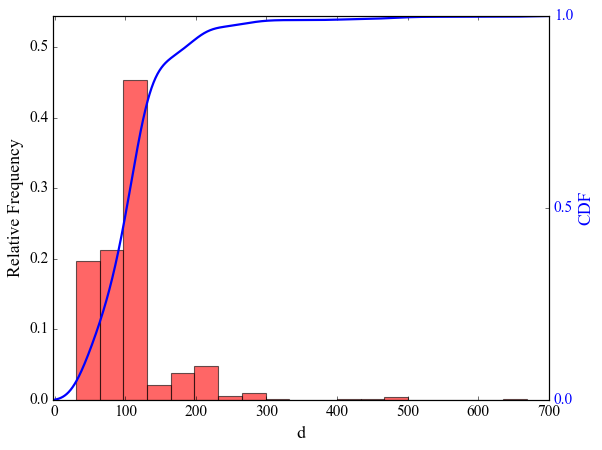

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)
reinforcement_data = data["d"]  # 열 이름 수정

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
ax1.set_xlabel("d", fontsize=16)
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "1. d.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()

#### 2. h (slab_depth)

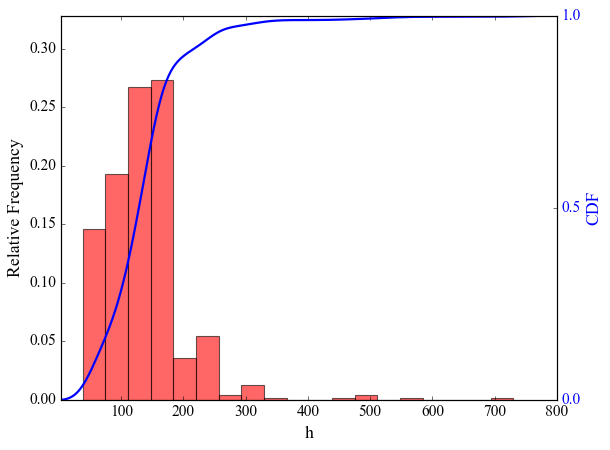

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)
reinforcement_data = data["h"]  # 열 이름 수정

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
ax1.set_xlabel("h", fontsize=16)
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(x_min, 800)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "2. h.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()

#### 3. b_0

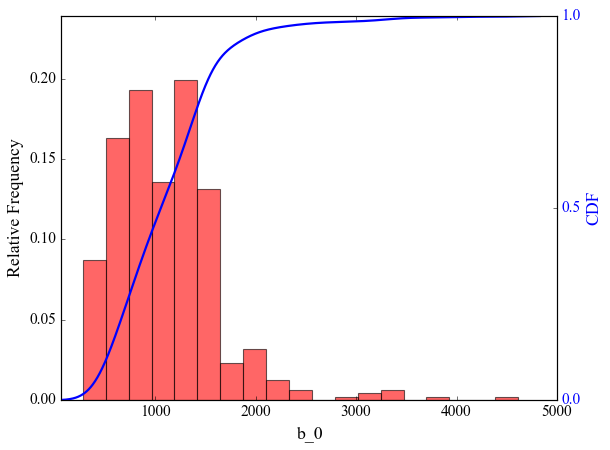

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)
reinforcement_data = data["b_0"]  # 열 이름 수정

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
ax1.set_xlabel("b_0", fontsize=16)
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(x_min, 5000)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "3. b_0.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()

#### 4. b

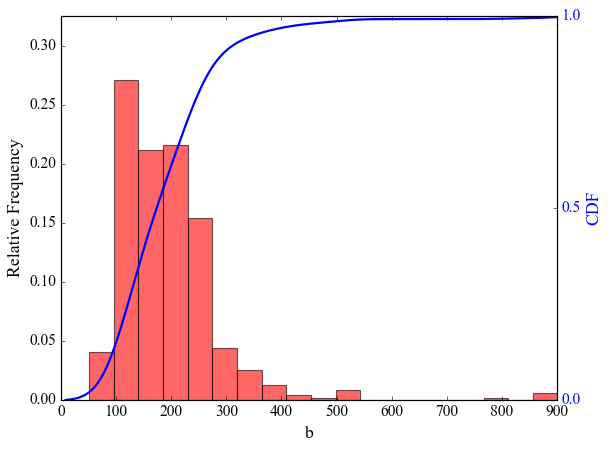

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["b"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("b", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, 900)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "4. b.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()

#### 5. A

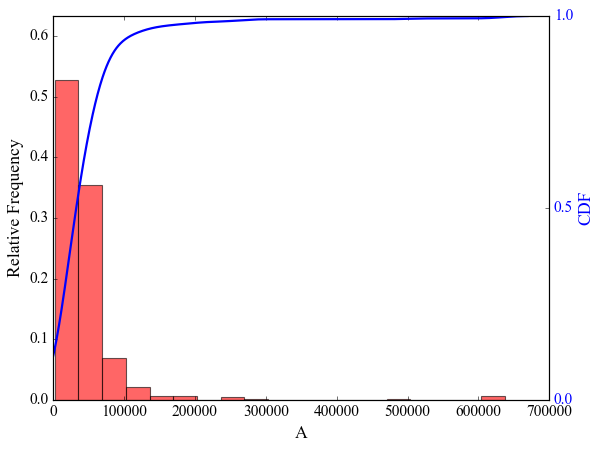

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["A"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("A", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
# ax1.set_xlim(0, x_max)
ax1.set_xlim(0, 700000)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "5. A.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 6. b_h_col

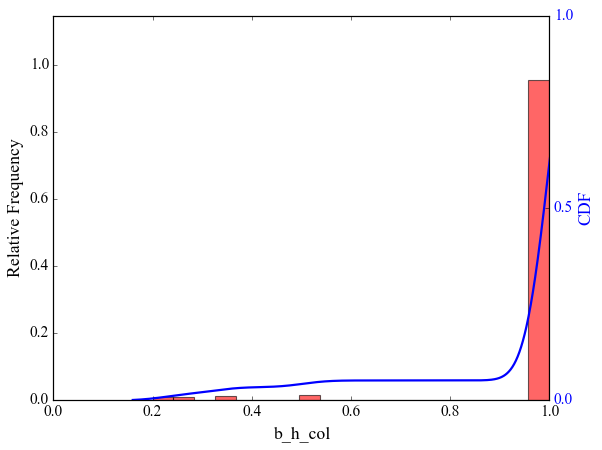

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["b_h_col"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("b_h_col", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
# ax1.set_xlim(0, x_max)
ax1.set_xlim(0, 1)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "6. b_h_col.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 7. fc

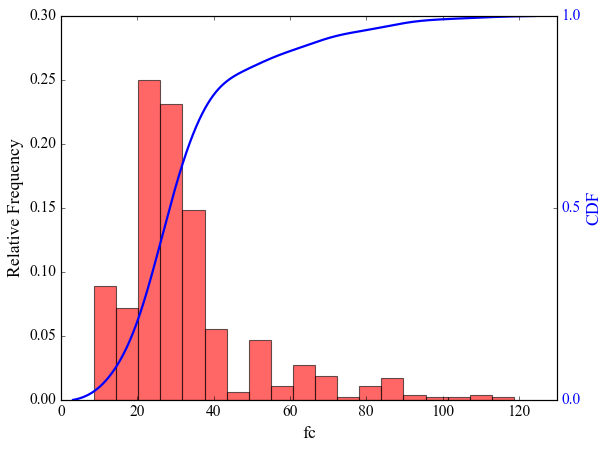

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["fc"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("fc", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, 130)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "7. fc.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 8. fy

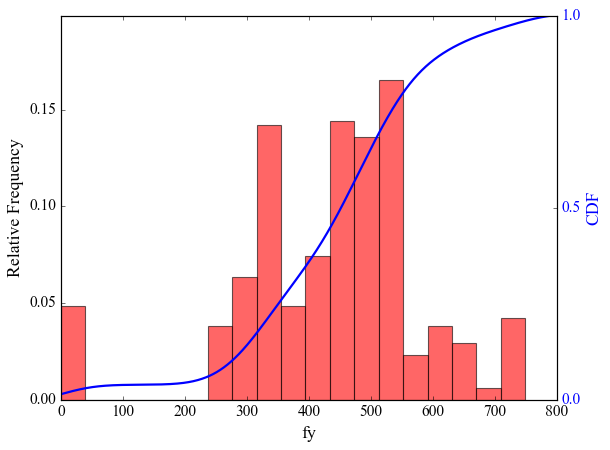

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["fy"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("fy", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, 800)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "8. fy.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 9. r

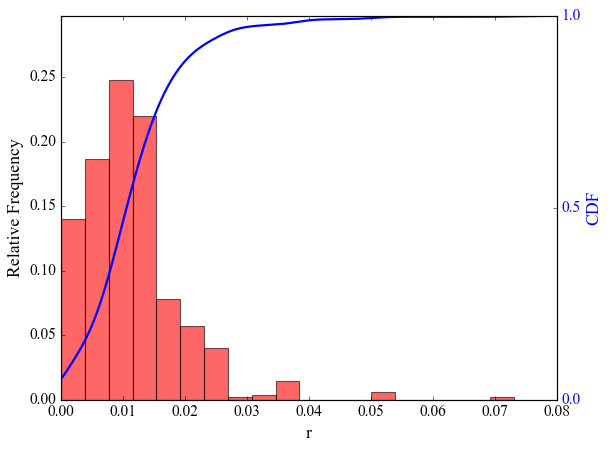

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["r"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("r", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, 0.08)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "9. r.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")



plt.show()

#### 10. a_d

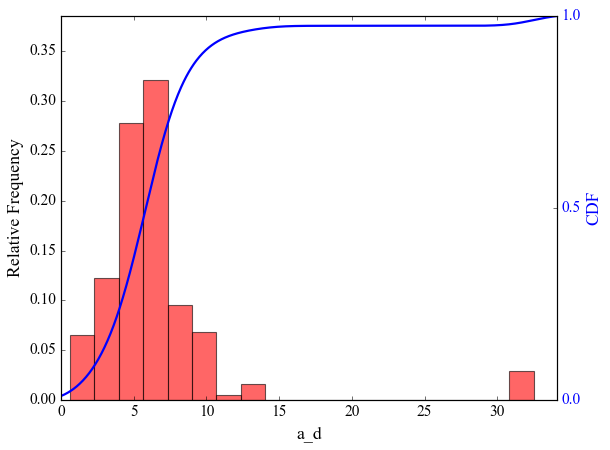

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

# 3. 결측값 및 무한값 자동 제거
reinforcement_data = data["a_d"]
reinforcement_data = reinforcement_data.replace([np.inf, -np.inf], np.nan)
reinforcement_data = reinforcement_data.dropna()

# 4. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 5. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 6. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 7. 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2

# 8. 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 9. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
ax1.set_xlabel("a_d", fontsize=16)
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, x_max)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 10. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "10. a_d.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 11. fy_fc

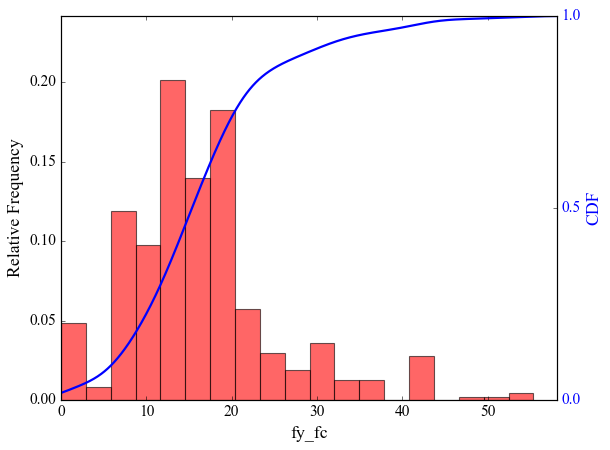

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["fy_fc"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("fy_fc", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, x_max)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "11. fy_fc.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 12. b_d

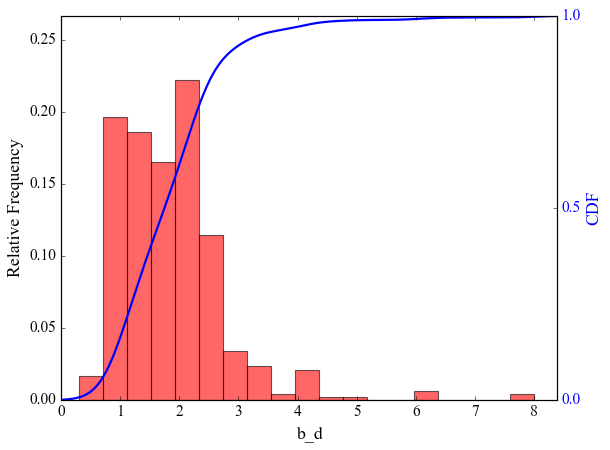

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 새로운 데이터 불러오기
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

######################################################################
reinforcement_data = data["b_d"]  # 열 이름 수정
######################################################################

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(reinforcement_data) / len(reinforcement_data)

# 4. 히스토그램의 구간(bins) 설정 (데이터 최소~최대값 사이 20구간)
bin_min = reinforcement_data.min()
bin_max = reinforcement_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 자동 설정 (데이터 범위에 5% 여유)
margin = (bin_max - bin_min) * 0.05
x_min = bin_min - margin
x_max = bin_max + margin

# 히스토그램 상대빈도 계산 (y축 범위 설정용)
counts, _ = np.histogram(reinforcement_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.2  # 최대값에 20% 여유

# 오른쪽 y축(CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: 히스토그램 그리기
ax1.hist(
    reinforcement_data,
    bins=bins,
    weights=weights,
    color="red",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
######################################################################
ax1.set_xlabel("b_d", fontsize=16)
######################################################################
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(0, x_max)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 CDF 곡선 그리기
grid_x = np.linspace(x_min, x_max, 1000)
try:
    kde = gaussian_kde(reinforcement_data)
    density = kde(grid_x)
    cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
    cum = cum / cum[-1]
    ax2 = ax1.twinx()
    ax2.plot(grid_x, cum, color="blue", lw=2, label="CDF")
    ax2.set_ylabel("CDF", color="blue", fontsize=16)
    ax2.set_ylim(y2_min, y2_max)
    ax2.tick_params(axis="y", labelcolor="blue", labelsize=14)
    ax2.set_yticks(np.arange(0, 1.01, 0.5))
except Exception as e:
    print("CDF 계산 오류:", e)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "12. b_d.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")


plt.show()

#### 13. Pu

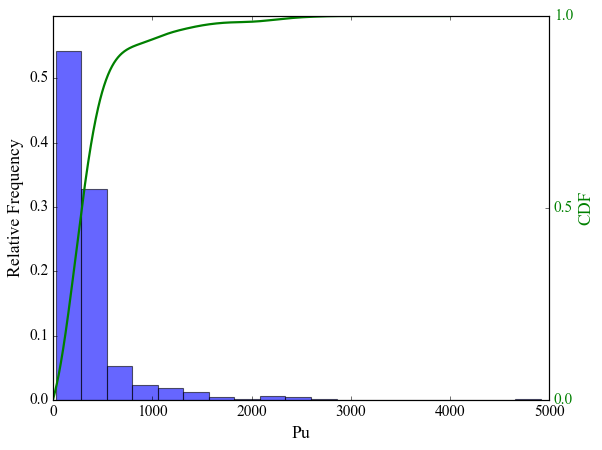

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 스타일 설정: 배경 흰색, 글꼴은 Times New Roman, 기본 폰트 크기 확대
plt.style.use("classic")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 14

# 2. 데이터 불러오기: 엑셀 파일에서 "Pu" 열의 데이터를 읽어옵니다.
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)
pu_data = data["Vn"]  # 엑셀 파일에 "Pu" 열이 있다고 가정합니다.

# 3. 히스토그램(상대빈도) 계산을 위한 가중치 설정
weights = np.ones_like(pu_data) / len(pu_data)

# 4. 히스토그램의 구간(bins) 설정
#    데이터의 최소값부터 최대값까지 20구간으로 나눕니다.
bin_min = pu_data.min()
bin_max = pu_data.max()
bins = np.linspace(bin_min, bin_max, 20)

# 5. x축 범위 설정: 데이터 범위에 약 5%의 여백 추가
margin = (bin_max - bin_min) * 0.05
x_min = 0
x_max = 4000

# 히스토그램 상대빈도 계산 (왼쪽 y축 범위 설정용)
counts, _ = np.histogram(pu_data, bins=bins, weights=weights)
y1_min = 0
y1_max = counts.max() * 1.1  # 최대값에 10% 여유

# 오른쪽 y축 (CDF) 범위: 0 ~ 1
y2_min, y2_max = 0, 1

# 6. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(8, 6))

# 6-1. 왼쪽 y축: Pu 데이터의 상대빈도 히스토그램 그리기
ax1.hist(
    pu_data,
    bins=bins,
    weights=weights,
    color="blue",
    alpha=0.6,
    edgecolor="black",
    label="Relative Frequencies",
)
ax1.set_xlabel("Pu", fontsize=16)
ax1.set_ylabel("Relative Frequency", fontsize=16)
ax1.set_xlim(x_min, 5000)
ax1.set_ylim(y1_min, y1_max)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

# 6-2. 오른쪽 y축: 누적 KDE를 이용해 부드러운 CDF 곡선 그리기
# x축 범위 내에서 균등하게 샘플링한 그리드 생성
grid_x = np.linspace(x_min, x_max, 1000)
# gaussian_kde로 밀도 추정
kde = gaussian_kde(pu_data)
density = kde(grid_x)
# 사다리꼴 적분으로 누적합 계산 후, 마지막 값으로 나눠 정규화 (마지막 값이 1이 됨)
cum = np.cumsum(density) * (grid_x[1] - grid_x[0])
cum = cum / cum[-1]

# 오른쪽 y축에 CDF 곡선 그리기
ax2 = ax1.twinx()
ax2.plot(grid_x, cum, color="green", lw=2, label="CDF")
ax2.set_ylabel("CDF", color="green", fontsize=16)
ax2.set_ylim(y2_min, y2_max)
ax2.tick_params(axis="y", labelcolor="green", labelsize=14)
# CDF y축 눈금을 0, 0.5, 1로 설정
ax2.set_yticks(np.arange(0, 1.01, 0.5))

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "13. Pu.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")



plt.show()

### Fig. 4. Correlation coefficients between input variables

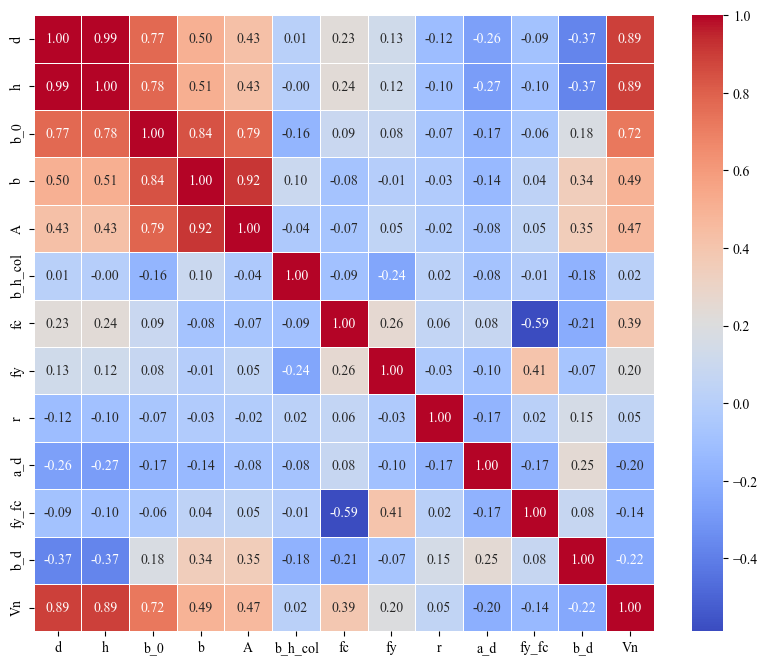

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 엑셀 파일 읽어오기 (파일 경로를 본인 환경에 맞게 수정)
file_path = "../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx"
data = pd.read_excel(file_path)

# 2. 상관계수를 계산할 열만 선택하기
cols = [
    "d",
    "h",
    "b_0",
    "b",
    "A",
    "b_h_col",
    "fc",
    "fy",
    "r",
    "a_d",
    "fy_fc",
    "b_d",
    "Vn"
]
data_selected = data[cols]

# 3. 상관계수 행렬 계산
corr_matrix = data_selected.corr()

plt.rcParams["font.family"] = "Times New Roman"

# 4. 상관계수 행렬을 히트맵으로 표현하기
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# 7. PDF로 저장 (폴더 자동 생성)
import os
save_dir = "데이터 분포 그래프"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "correlation.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()

### Model selection compare

데이터 형태: (472, 12)
입력 변수: ['d', 'h', 'b_0', 'b', 'A', 'b_h_col', 'fc', 'fy', 'r', 'a_d', 'fy_fc', 'b_d']
출력 변수: Vn
------------------------------------------------------------
Linear Regression   : R² = 0.7954
Decision Tree       : R² = -1.3160
SVR                 : R² = -0.0287
Random Forest       : R² = 0.8507
AdaBoost            : R² = 0.8224
Gradient Boost      : R² = 0.8574
XGBoost             : R² = 0.8728
ANN                 : R² = 0.8661
------------------------------------------------------------

=== 모델 성능 순위 (R² 점수 기준) ===
1. XGBoost             : R² = 0.8728
2. ANN                 : R² = 0.8661
3. Gradient Boost      : R² = 0.8574
4. Random Forest       : R² = 0.8507
5. AdaBoost            : R² = 0.8224
6. Linear Regression   : R² = 0.7954
7. SVR                 : R² = -0.0287
8. Decision Tree       : R² = -1.3160

최고 성능 모델: XGBoost (R² = 0.8728)


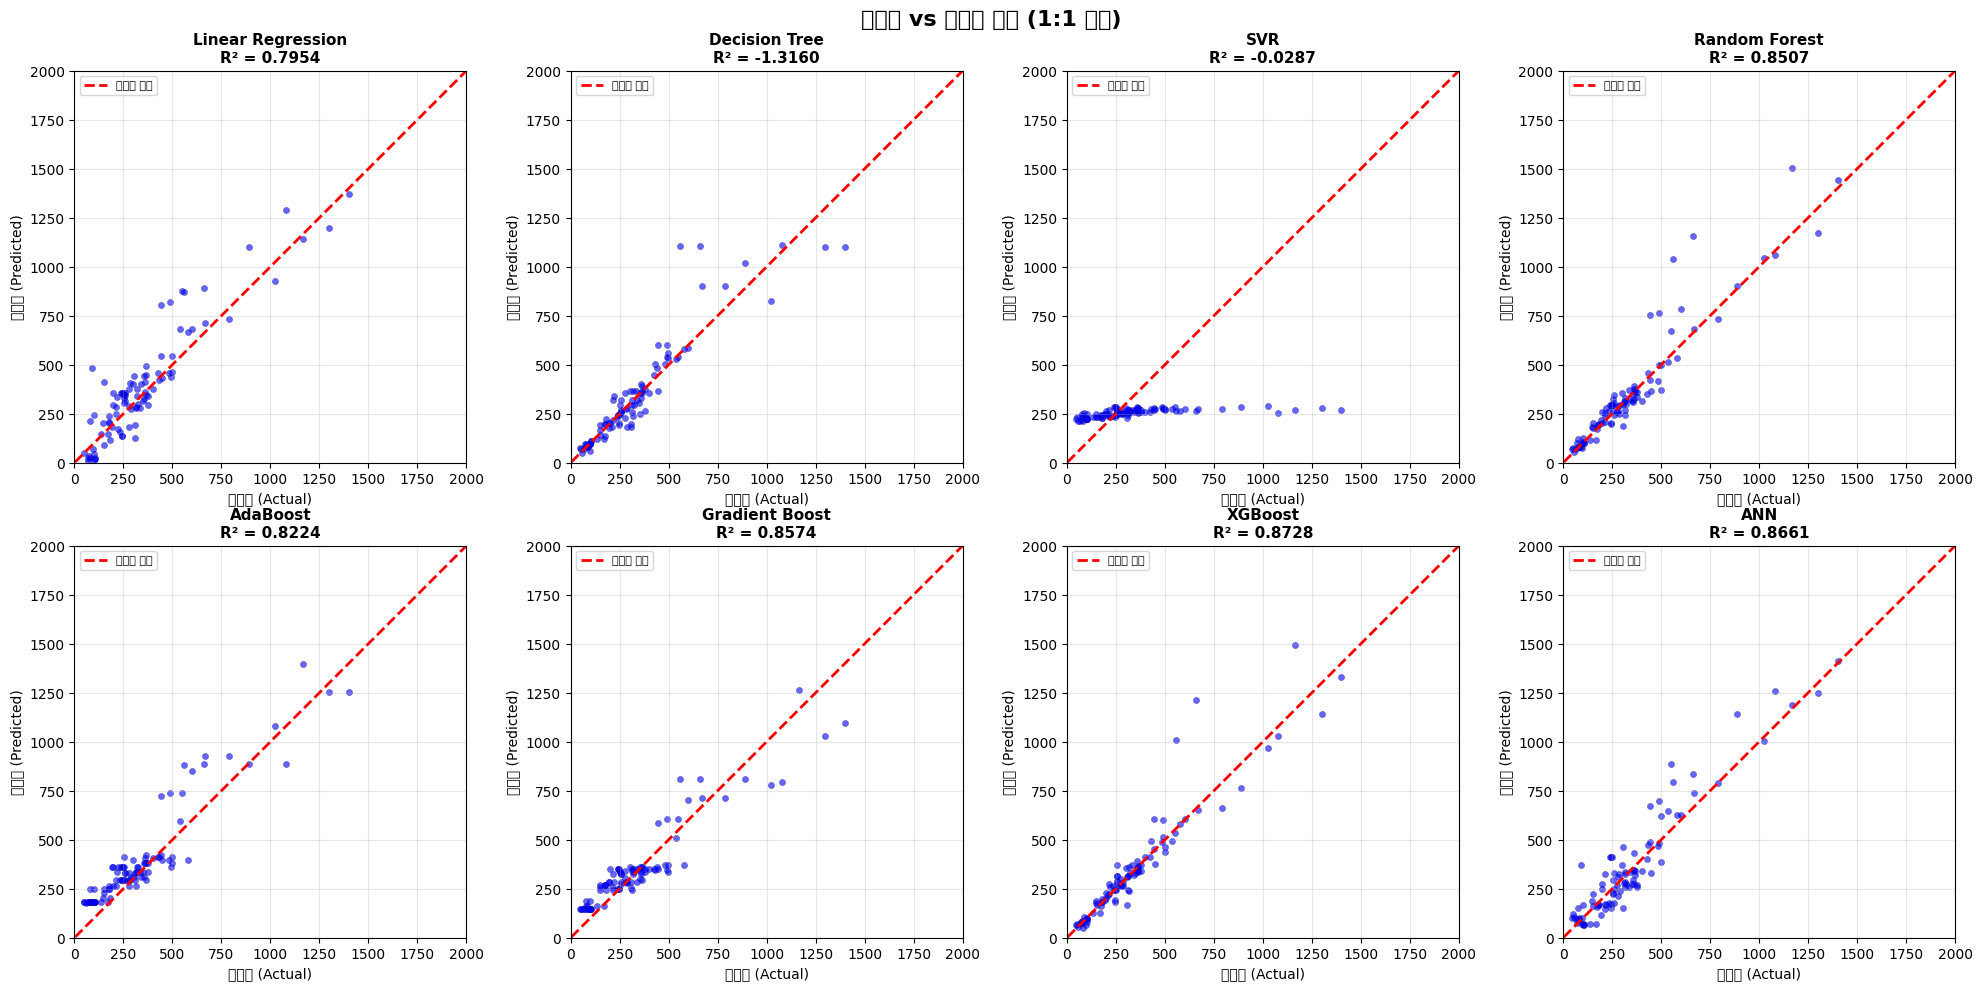

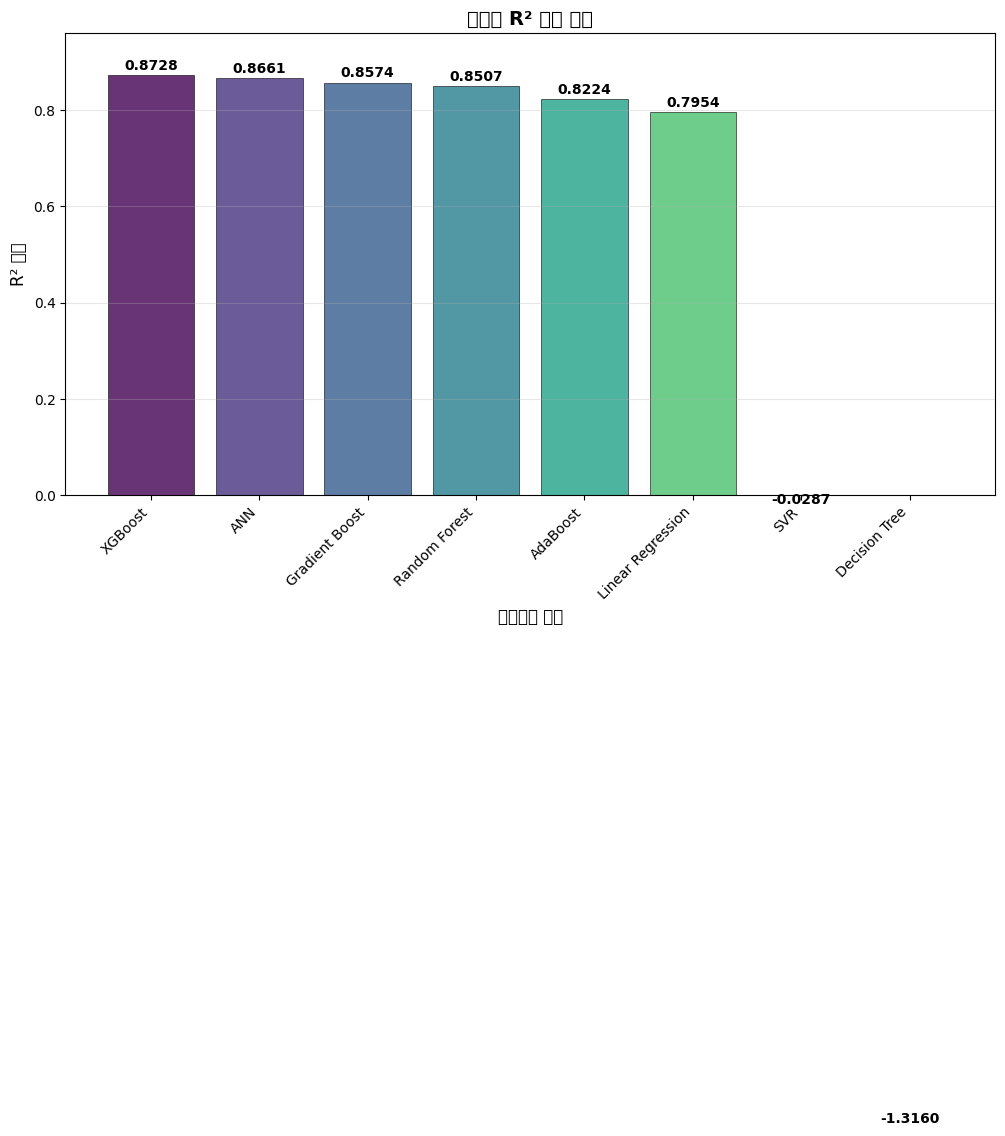


=== 상세 통계 정보 ===

XGBoost:
  R² 점수: 0.8728
  MAE (평균절대오차): 44.23
  MSE (평균제곱오차): 8686.04
  RMSE (평균제곱근오차): 93.20

ANN:
  R² 점수: 0.8661
  MAE (평균절대오차): 69.45
  MSE (평균제곱오차): 9145.06
  RMSE (평균제곱근오차): 95.63

Gradient Boost:
  R² 점수: 0.8574
  MAE (평균절대오차): 76.66
  MSE (평균제곱오차): 9736.06
  RMSE (평균제곱근오차): 98.67

Random Forest:
  R² 점수: 0.8507
  MAE (평균절대오차): 52.18
  MSE (평균제곱오차): 10196.09
  RMSE (평균제곱근오차): 100.98

AdaBoost:
  R² 점수: 0.8224
  MAE (평균절대오차): 86.02
  MSE (평균제곱오차): 12130.93
  RMSE (평균제곱근오차): 110.14

Linear Regression:
  R² 점수: 0.7954
  MAE (평균절대오차): 88.26
  MSE (평균제곱오차): 13972.02
  RMSE (평균제곱근오차): 118.20

SVR:
  R² 점수: -0.0287
  MAE (평균절대오차): 160.65
  MSE (평균제곱오차): 70251.26
  RMSE (평균제곱근오차): 265.05

Decision Tree:
  R² 점수: -1.3160
  MAE (평균절대오차): 93.11
  MSE (평균제곱오차): 158159.38
  RMSE (평균제곱근오차): 397.69


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Excel 파일 읽기
df = pd.read_excel('../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx')

# 입력 변수와 출력 변수 정의
input_features = ['d', 'h', 'b_0', 'b', 'A', 'b_h_col', 'fc', 'fy', 'r', 'a_d', 'fy_fc', 'b_d']
target = 'Vn'

# 데이터 준비
X = df[input_features]
y = df[target]

print(f"데이터 형태: {X.shape}")
print(f"입력 변수: {input_features}")
print(f"출력 변수: {target}")
print("-" * 60)

# 훈련/테스트 데이터 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화 (일부 모델에 필요)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델 정의
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(kernel='rbf', gamma='scale'),
    "Random Forest": RandomForestRegressor(n_estimators=35, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "Gradient Boost": GradientBoostingRegressor(n_estimators=15, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42),
    "ANN": MLPRegressor(hidden_layer_sizes=(10, 50), max_iter=1000, random_state=42)
}

# 각 모델의 R² 점수 계산 및 예측값 저장
results = {}
predictions = {}

for name, model in models.items():
    try:
        if name in ["SVR", "ANN"]:
            # 정규화된 데이터 사용
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            # 원본 데이터 사용
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        results[name] = r2
        predictions[name] = y_pred
        print(f"{name:20s}: R² = {r2:.4f}")
        
    except Exception as e:
        print(f"{name:20s}: 오류 발생 - {str(e)}")

print("-" * 60)

# 결과 정렬 (R² 점수 기준 내림차순)
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n=== 모델 성능 순위 (R² 점수 기준) ===")
for i, (name, r2) in enumerate(sorted_results, 1):
    print(f"{i}. {name:20s}: R² = {r2:.4f}")

# 최고 성능 모델
best_model_name, best_r2 = sorted_results[0]
print(f"\n최고 성능 모델: {best_model_name} (R² = {best_r2:.4f})")

# 1:1 플롯 그리기 (실제값 vs 예측값)
plt.rcParams['font.family'] = 'DejaVu Sans'  # 한글 폰트 설정 (필요시 변경)
plt.style.use('default')

# 2x4 서브플롯 생성
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('실제값 vs 예측값 비교 (1:1 플롯)', fontsize=16, fontweight='bold')

# 전체 데이터 범위 계산 (모든 그래프의 축을 동일하게 설정)
y_min = min(y_test.min(), min([pred.min() for pred in predictions.values()]))
y_max = max(y_test.max(), max([pred.max() for pred in predictions.values()]))
margin = (y_max - y_min) * 0.05
y_min -= margin
y_max += margin

# 각 모델별 1:1 플롯
for idx, (name, y_pred) in enumerate(predictions.items()):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # 산점도
    ax.scatter(y_test, y_pred, alpha=0.6, s=20, color='blue', edgecolors='navy', linewidth=0.3)
    
    # 완벽한 예측선 (y=x)
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=2, label='완벽한 예측')
    
    # 그래프 설정
    ax.set_xlim(y_min, y_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('실제값 (Actual)', fontsize=10)
    ax.set_ylabel('예측값 (Predicted)', fontsize=10)
    ax.set_title(f'{name}\nR² = {results[name]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 2000)
    ax.set_ylim(0, 2000)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # 축 비율을 같게 설정
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('모델 비교.pdf', format="pdf", bbox_inches="tight")
plt.show()

# 성능 비교 바 차트
plt.figure(figsize=(12, 6))
names = [name for name, _ in sorted_results]
r2_scores = [r2 for _, r2 in sorted_results]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))

bars = plt.bar(names, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# 바 위에 R² 값 표시
for bar, r2 in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{r2:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('머신러닝 모델', fontsize=12)
plt.ylabel('R² 점수', fontsize=12)
plt.title('모델별 R² 점수 비교', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(r2_scores) * 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 상세 통계 정보
print("\n" + "="*80)
print("=== 상세 통계 정보 ===")
print("="*80)

for name, r2 in sorted_results:
    y_pred = predictions[name]
    mae = np.mean(np.abs(y_test - y_pred))
    mse = np.mean((y_test - y_pred)**2)
    rmse = np.sqrt(mse)
    
    print(f"\n{name}:")
    print(f"  R² 점수: {r2:.4f}")
    print(f"  MAE (평균절대오차): {mae:.2f}")
    print(f"  MSE (평균제곱오차): {mse:.2f}")
    print(f"  RMSE (평균제곱근오차): {rmse:.2f}")

### 입력변수 조합

PDF 저장 폴더 생성: XGBoost_Analysis_PDFs
데이터 형태: (472, 12)
입력 변수: ['d', 'h', 'b_0', 'b', 'A', 'b_h_col', 'fc', 'fy', 'r', 'a_d', 'fy_fc', 'b_d']
출력 변수: Vn
--------------------------------------------------------------------------------
XGBoost 입력변수 조합 최적화 시작...
--------------------------------------------------------------------------------
테스트할 총 조합 개수: 4083

=== 2개 변수 조합 테스트 중... ===
  10/66 완료 - 현재 최고 R²: 0.8778
  20/66 완료 - 현재 최고 R²: 0.8806
  30/66 완료 - 현재 최고 R²: 0.8806
  40/66 완료 - 현재 최고 R²: 0.8806
  50/66 완료 - 현재 최고 R²: 0.8806
  60/66 완료 - 현재 최고 R²: 0.8806
  66/66 완료 - 현재 최고 R²: 0.8806

=== 3개 변수 조합 테스트 중... ===
  10/220 완료 - 현재 최고 R²: 0.8806
  20/220 완료 - 현재 최고 R²: 0.8855
  30/220 완료 - 현재 최고 R²: 0.8963
  40/220 완료 - 현재 최고 R²: 0.9076
  50/220 완료 - 현재 최고 R²: 0.9116
  60/220 완료 - 현재 최고 R²: 0.9116
  70/220 완료 - 현재 최고 R²: 0.9116
  80/220 완료 - 현재 최고 R²: 0.9231
  90/220 완료 - 현재 최고 R²: 0.9231
  100/220 완료 - 현재 최고 R²: 0.9247
  110/220 완료 - 현재 최고 R²: 0.9247
  120/220 완료 - 현재 최고 R²: 0.9247
  13

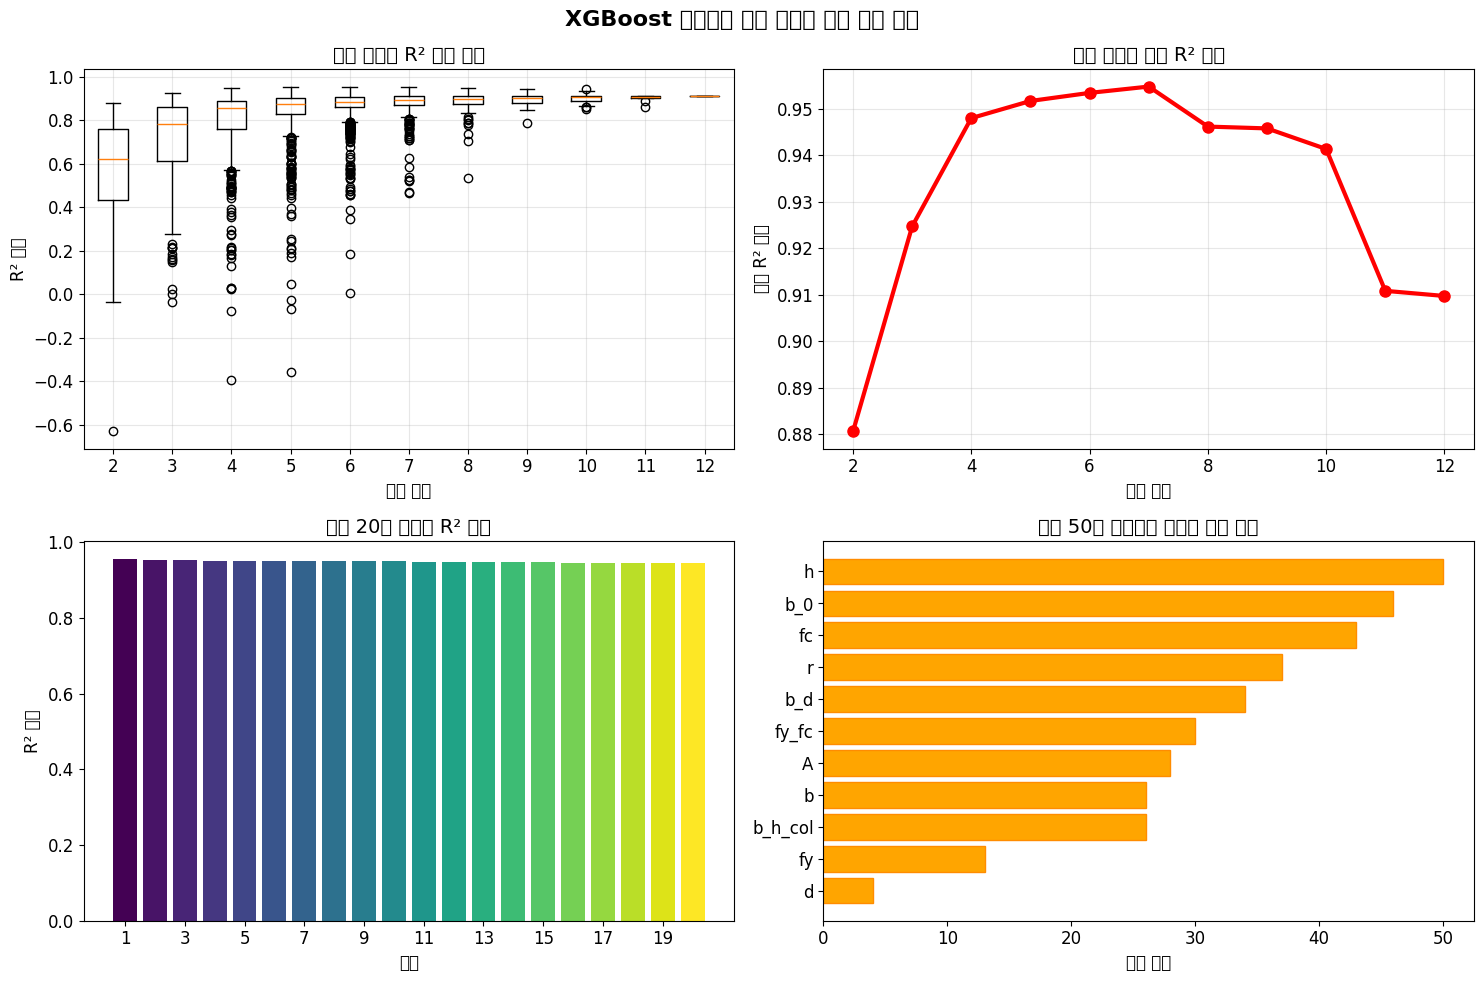

✓ 저장 완료: XGBoost_Analysis_PDFs/02_최적모델_1대1플롯.pdf


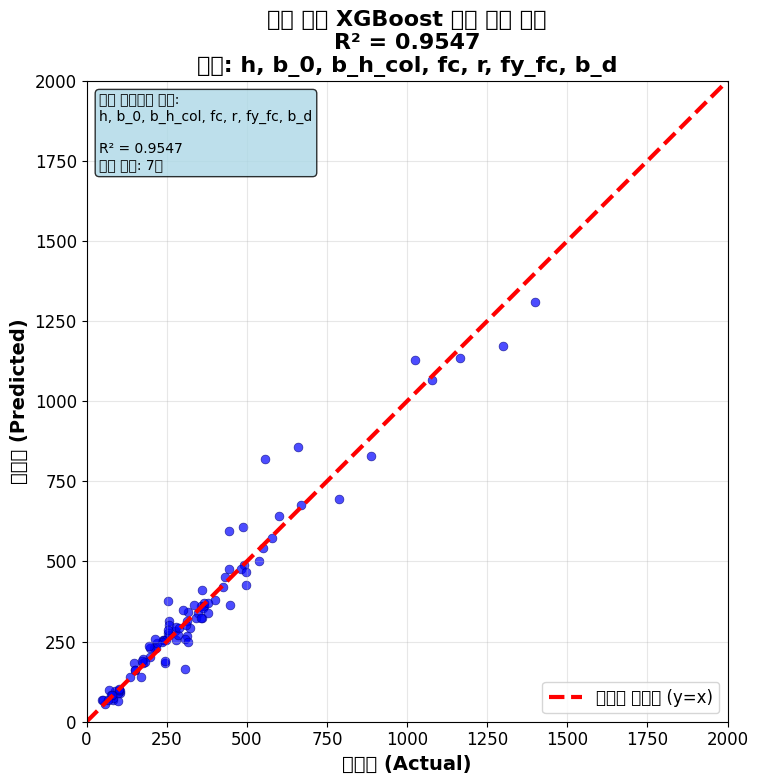

✓ 저장 완료: XGBoost_Analysis_PDFs/03_최적모델_변수중요도.pdf


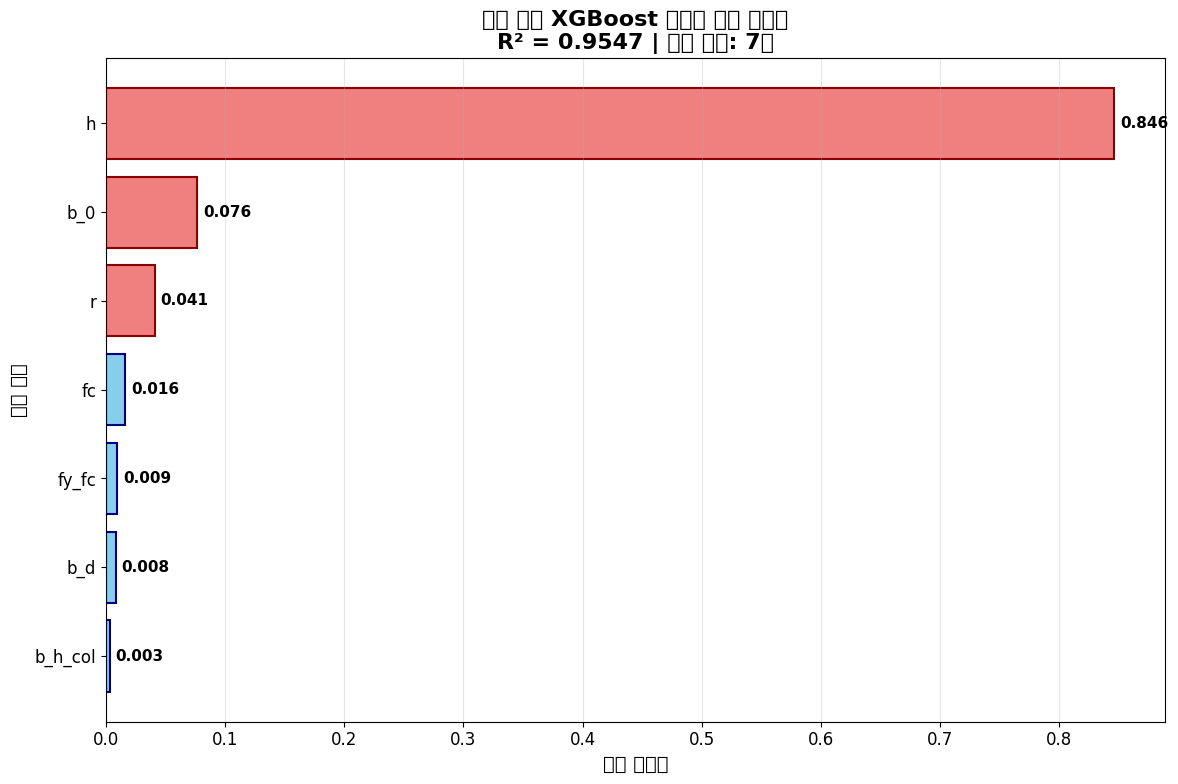

✓ 저장 완료: XGBoost_Analysis_PDFs/04_상위조합_상세분석.pdf


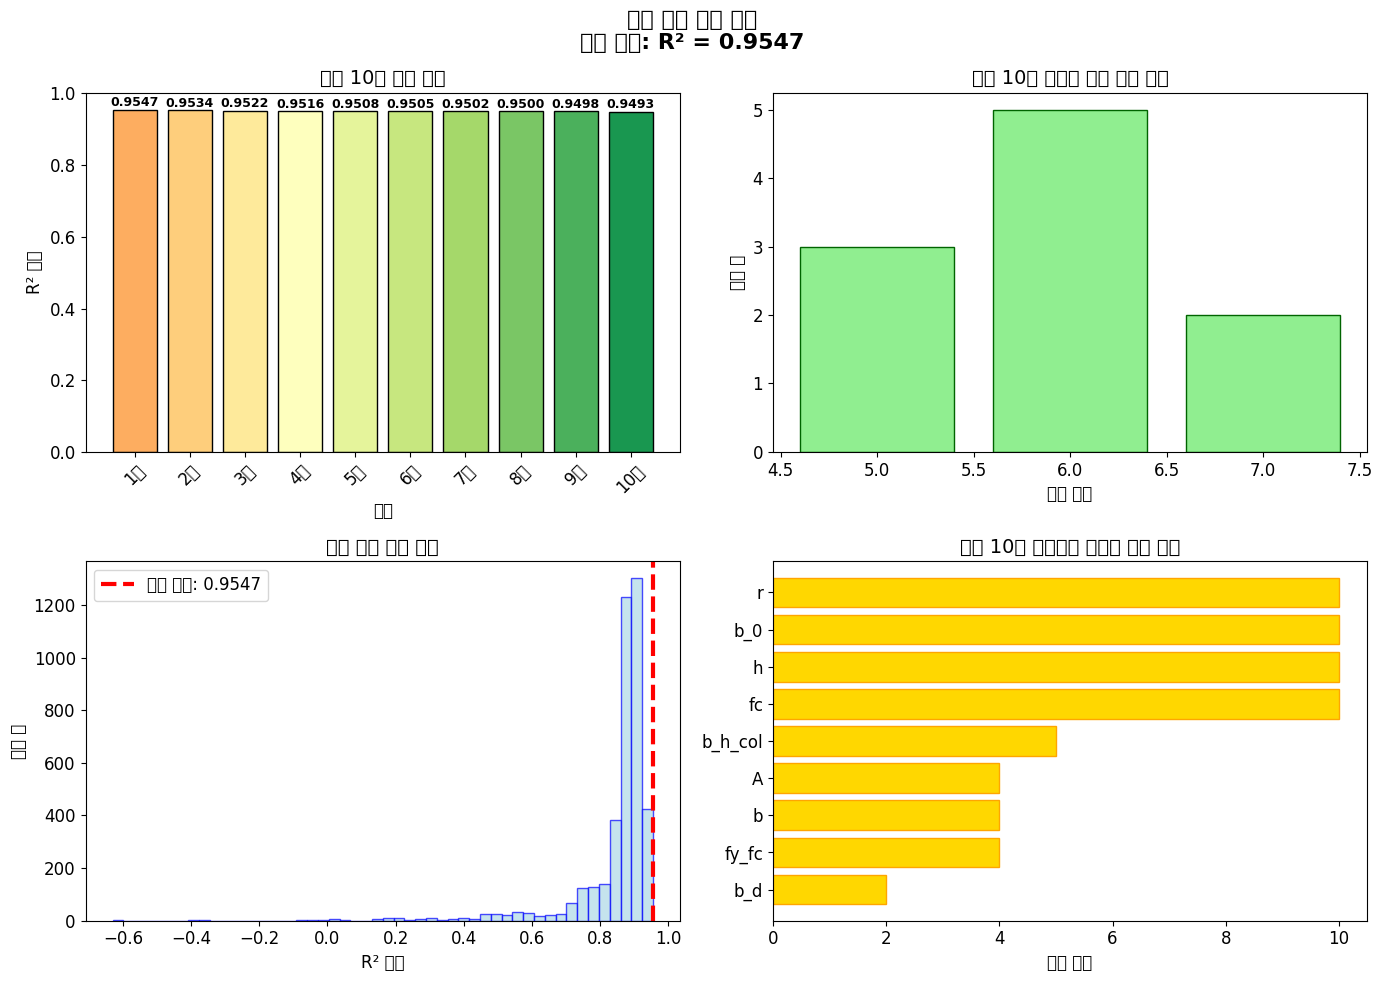

✓ 저장 완료: XGBoost_Analysis_PDFs/05_최적화결과_요약.txt

=== 최적 모델 변수 중요도 ===
 1. h         : 0.8461
 2. b_0       : 0.0765
 3. r         : 0.0409
 4. fc        : 0.0159
 5. fy_fc     : 0.0093
 6. b_d       : 0.0082
 7. b_h_col   : 0.0031

=== PDF 저장 완료 ===
모든 그래프와 결과가 'XGBoost_Analysis_PDFs' 폴더에 저장되었습니다:
  1. 01_종합분석_변수조합최적화.pdf
  2. 02_최적모델_1대1플롯.pdf
  3. 03_최적모델_변수중요도.pdf
  4. 04_상위조합_상세분석.pdf
  5. 05_최적화결과_요약.txt


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import xgboost as xgb
from itertools import combinations
import warnings
import time
import os
from matplotlib.backends.backend_pdf import PdfPages
warnings.filterwarnings('ignore')

# PDF 저장 폴더 생성
pdf_folder = 'XGBoost_Analysis_PDFs'
if not os.path.exists(pdf_folder):
    os.makedirs(pdf_folder)
    print(f"PDF 저장 폴더 생성: {pdf_folder}")

# Excel 파일 읽기
df = pd.read_excel('../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx')

# 입력 변수와 출력 변수 정의
input_features = ['d', 'h', 'b_0', 'b', 'A', 'b_h_col', 'fc', 'fy', 'r', 'a_d', 'fy_fc', 'b_d']
target = 'Vn'

# 데이터 준비
X = df[input_features]
y = df[target]

print(f"데이터 형태: {X.shape}")
print(f"입력 변수: {input_features}")
print(f"출력 변수: {target}")

# 훈련/테스트 데이터 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("-" * 80)
print("XGBoost 입력변수 조합 최적화 시작...")
print("-" * 80)

# 결과를 저장할 리스트
results = []
best_r2 = -float('inf')
best_combination = None
best_model = None

# 총 조합 개수 계산 및 출력
total_combinations = sum(len(list(combinations(input_features, i))) for i in range(2, len(input_features) + 1))
print(f"테스트할 총 조합 개수: {total_combinations}")
print()

start_time = time.time()

# 2개부터 최대 개수까지의 모든 조합 테스트
for num_features in range(2, len(input_features) + 1):
    print(f"=== {num_features}개 변수 조합 테스트 중... ===")
    
    # 현재 변수 개수에 대한 모든 조합 생성
    feature_combinations = list(combinations(input_features, num_features))
    
    for idx, feature_combo in enumerate(feature_combinations):
        try:
            # 현재 조합의 변수들로 데이터 준비
            X_train_combo = X_train[list(feature_combo)]
            X_test_combo = X_test[list(feature_combo)]
            
            # XGBoost 모델 훈련
            model = xgb.XGBRegressor(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1
            )
            
            model.fit(X_train_combo, y_train)
            y_pred = model.predict(X_test_combo)
            
            # R² 계산
            r2 = r2_score(y_test, y_pred)
            
            # 결과 저장
            result = {
                'num_features': num_features,
                'features': feature_combo,
                'r2_score': r2,
                'feature_names': ', '.join(feature_combo)
            }
            results.append(result)
            
            # 최고 성능 업데이트
            if r2 > best_r2:
                best_r2 = r2
                best_combination = feature_combo
                best_model = model
            
            # 진행상황 출력 (10개마다)
            if (idx + 1) % 10 == 0 or (idx + 1) == len(feature_combinations):
                print(f"  {idx + 1}/{len(feature_combinations)} 완료 - 현재 최고 R²: {best_r2:.4f}")
                
        except Exception as e:
            print(f"  오류 발생 (조합 {idx+1}): {str(e)}")
    
    print()

end_time = time.time()
execution_time = end_time - start_time

print("=" * 80)
print("=== 최적화 완료 ===")
print("=" * 80)
print(f"실행 시간: {execution_time:.2f}초")
print(f"테스트된 조합 개수: {len(results)}")
print(f"최고 R² 점수: {best_r2:.4f}")
print(f"최적 입력변수 조합 ({len(best_combination)}개):")
for i, feature in enumerate(best_combination, 1):
    print(f"  {i}. {feature}")

# 결과 DataFrame 생성
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('r2_score', ascending=False).reset_index(drop=True)

# 상위 10개 조합 출력
print("\n" + "=" * 80)
print("=== 상위 10개 조합 ===")
print("=" * 80)
for i in range(min(10, len(results_df))):
    row = results_df.iloc[i]
    print(f"{i+1:2d}. R² = {row['r2_score']:.4f} | {row['num_features']}개 변수 | {row['feature_names']}")

# 변수 개수별 최고 성능 분석
print("\n" + "=" * 80)
print("=== 변수 개수별 최고 R² 점수 ===")
print("=" * 80)
for num in range(2, len(input_features) + 1):
    subset = results_df[results_df['num_features'] == num]
    if not subset.empty:
        best_for_num = subset.iloc[0]
        print(f"{num:2d}개 변수: R² = {best_for_num['r2_score']:.4f} | {best_for_num['feature_names']}")

# 시각화 1: 변수 개수별 R² 점수 분포 (PDF 저장)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"\n그래프를 PDF로 저장 중...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('XGBoost 입력변수 조합 최적화 결과 종합 분석', fontsize=16, fontweight='bold')

# 서브플롯 1: 변수 개수별 R² 점수 박스플롯
ax1 = axes[0, 0]
box_data = [results_df[results_df['num_features'] == num]['r2_score'].values 
            for num in range(2, len(input_features) + 1)]
ax1.boxplot(box_data, labels=range(2, len(input_features) + 1))
ax1.set_xlabel('변수 개수')
ax1.set_ylabel('R² 점수')
ax1.set_title('변수 개수별 R² 점수 분포')
ax1.grid(True, alpha=0.3)

# 서브플롯 2: 변수 개수별 최고 R² 점수
ax2 = axes[0, 1]
max_r2_by_num = results_df.groupby('num_features')['r2_score'].max()
ax2.plot(max_r2_by_num.index, max_r2_by_num.values, 'o-', linewidth=3, markersize=8, color='red')
ax2.set_xlabel('변수 개수')
ax2.set_ylabel('최고 R² 점수')
ax2.set_title('변수 개수별 최고 R² 점수')
ax2.grid(True, alpha=0.3)

# 서브플롯 3: 상위 20개 조합의 R² 점수
ax3 = axes[1, 0]
top_20 = results_df.head(20)
bars = ax3.bar(range(len(top_20)), top_20['r2_score'], 
               color=plt.cm.viridis(np.linspace(0, 1, len(top_20))))
ax3.set_xlabel('순위')
ax3.set_ylabel('R² 점수')
ax3.set_title('상위 20개 조합의 R² 점수')
ax3.set_xticks(range(0, len(top_20), 2))
ax3.set_xticklabels(range(1, len(top_20)+1, 2))

# 서브플롯 4: 변수별 등장 빈도 (상위 50개 조합에서)
ax4 = axes[1, 1]
top_50 = results_df.head(50)
feature_count = {}
for _, row in top_50.iterrows():
    for feature in row['features']:
        feature_count[feature] = feature_count.get(feature, 0) + 1

feature_freq = pd.Series(feature_count).sort_values(ascending=True)
ax4.barh(feature_freq.index, feature_freq.values, color='orange', edgecolor='darkorange')
ax4.set_xlabel('등장 빈도')
ax4.set_title('상위 50개 조합에서 변수별 등장 빈도')

plt.tight_layout()
plt.savefig(f'{pdf_folder}/01_종합분석_변수조합최적화.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/01_종합분석_변수조합최적화.pdf")
plt.show()

# 시각화 2: 최적 모델 1:1 플롯 (PDF 저장)
plt.figure(figsize=(10, 8))
X_test_best = X_test[list(best_combination)]
y_pred_best = best_model.predict(X_test_best)

plt.scatter(y_test, y_pred_best, alpha=0.7, s=40, color='blue', edgecolors='navy', linewidth=0.5)
plt.plot([0, 2000], [0, 2000], 'r--', linewidth=3, label='완벽한 예측선 (y=x)')

plt.xlabel('실제값 (Actual)', fontsize=14, fontweight='bold')
plt.ylabel('예측값 (Predicted)', fontsize=14, fontweight='bold')
plt.title(f'최적 조합 XGBoost 모델 예측 성능\nR² = {best_r2:.4f}\n변수: {", ".join(best_combination)}', 
          fontsize=16, fontweight='bold')
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# 성능 지표 텍스트 박스 추가
textstr = f'최적 입력변수 조합:\n{", ".join(best_combination)}\n\nR² = {best_r2:.4f}\n변수 개수: {len(best_combination)}개'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig(f'{pdf_folder}/02_최적모델_1대1플롯.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/02_최적모델_1대1플롯.pdf")
plt.show()

# 시각화 3: 최적 모델의 변수 중요도 (PDF 저장)
feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': best_combination,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['feature'], importance_df['importance'], 
                color='skyblue', edgecolor='navy', linewidth=1.5)

# 중요도 값을 막대 끝에 표시
for i, (_, row) in enumerate(importance_df.iterrows()):
    plt.text(row['importance'] + 0.005, i, f'{row["importance"]:.3f}', 
             va='center', fontweight='bold', fontsize=11)

plt.xlabel('변수 중요도', fontsize=14, fontweight='bold')
plt.ylabel('입력 변수', fontsize=14, fontweight='bold')
plt.title(f'최적 조합 XGBoost 모델의 변수 중요도\nR² = {best_r2:.4f} | 변수 개수: {len(best_combination)}개', 
          fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# 상위 3개 변수 하이라이트
top_3_features = importance_df.tail(3)['feature'].tolist()
for i, bar in enumerate(bars):
    if importance_df.iloc[i]['feature'] in top_3_features:
        bar.set_color('lightcoral')
        bar.set_edgecolor('darkred')

plt.tight_layout()
plt.savefig(f'{pdf_folder}/03_최적모델_변수중요도.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/03_최적모델_변수중요도.pdf")
plt.show()

# 시각화 4: 상위 10개 조합 상세 비교 (PDF 저장)
plt.figure(figsize=(14, 10))

# 상위 10개 조합 데이터
top_10 = results_df.head(10)

# 서브플롯 1: R² 점수 바 차트
plt.subplot(2, 2, 1)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_10)))
bars = plt.bar(range(len(top_10)), top_10['r2_score'], color=colors, edgecolor='black')

# 바 위에 R² 값 표시
for i, (bar, r2) in enumerate(zip(bars, top_10['r2_score'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{r2:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.xlabel('순위')
plt.ylabel('R² 점수')
plt.title('상위 10개 조합 성능')
plt.xticks(range(len(top_10)), [f'{i+1}위' for i in range(len(top_10))], rotation=45)

# 서브플롯 2: 변수 개수 분포
plt.subplot(2, 2, 2)
feature_counts = top_10['num_features'].value_counts().sort_index()
plt.bar(feature_counts.index, feature_counts.values, color='lightgreen', edgecolor='darkgreen')
plt.xlabel('변수 개수')
plt.ylabel('조합 수')
plt.title('상위 10개 조합의 변수 개수 분포')

# 서브플롯 3: 성능 분포 히스토그램
plt.subplot(2, 2, 3)
plt.hist(results_df['r2_score'], bins=50, alpha=0.7, color='lightblue', edgecolor='blue')
plt.axvline(best_r2, color='red', linestyle='--', linewidth=3, label=f'최고 성능: {best_r2:.4f}')
plt.xlabel('R² 점수')
plt.ylabel('조합 수')
plt.title('전체 조합 성능 분포')
plt.legend()

# 서브플롯 4: 상위 조합 변수별 등장 빈도
plt.subplot(2, 2, 4)
top_10_features = {}
for _, row in top_10.iterrows():
    for feature in row['features']:
        top_10_features[feature] = top_10_features.get(feature, 0) + 1

feature_freq_top10 = pd.Series(top_10_features).sort_values(ascending=True)
plt.barh(feature_freq_top10.index, feature_freq_top10.values, color='gold', edgecolor='orange')
plt.xlabel('등장 횟수')
plt.title('상위 10개 조합에서 변수별 등장 빈도')

plt.suptitle(f'상위 조합 상세 분석\n최고 성능: R² = {best_r2:.4f}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{pdf_folder}/04_상위조합_상세분석.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/04_상위조합_상세분석.pdf")
plt.show()

# 결과 요약을 텍스트 파일로도 저장
with open(f'{pdf_folder}/05_최적화결과_요약.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("XGBoost 입력변수 조합 최적화 결과 요약\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"실행 시간: {execution_time:.2f}초\n")
    f.write(f"테스트된 조합 개수: {len(results)}\n")
    f.write(f"최고 R² 점수: {best_r2:.4f}\n")
    f.write(f"최적 입력변수 조합 ({len(best_combination)}개):\n")
    for i, feature in enumerate(best_combination, 1):
        f.write(f"  {i}. {feature}\n")
    
    f.write(f"\n상위 10개 조합:\n")
    f.write("-" * 60 + "\n")
    for i in range(min(10, len(results_df))):
        row = results_df.iloc[i]
        f.write(f"{i+1:2d}. R² = {row['r2_score']:.4f} | {row['num_features']}개 변수 | {row['feature_names']}\n")
    
    f.write(f"\n변수 개수별 최고 R² 점수:\n")
    f.write("-" * 60 + "\n")
    for num in range(2, len(input_features) + 1):
        subset = results_df[results_df['num_features'] == num]
        if not subset.empty:
            best_for_num = subset.iloc[0]
            f.write(f"{num:2d}개 변수: R² = {best_for_num['r2_score']:.4f} | {best_for_num['feature_names']}\n")
    
    f.write(f"\n최적 모델 변수 중요도:\n")
    f.write("-" * 60 + "\n")
    importance_df_sorted = importance_df.sort_values('importance', ascending=False)
    for i, (_, row) in enumerate(importance_df_sorted.iterrows(), 1):
        f.write(f"{i:2d}. {row['feature']:10s}: {row['importance']:.4f}\n")

print(f"✓ 저장 완료: {pdf_folder}/05_최적화결과_요약.txt")

print("\n" + "=" * 80)
print("=== 최적 모델 변수 중요도 ===")
print("=" * 80)
importance_df_sorted = importance_df.sort_values('importance', ascending=False)
for i, (_, row) in enumerate(importance_df_sorted.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:10s}: {row['importance']:.4f}")

print("\n" + "=" * 80)
print("=== PDF 저장 완료 ===")
print("=" * 80)
print(f"모든 그래프와 결과가 '{pdf_folder}' 폴더에 저장되었습니다:")
print(f"  1. 01_종합분석_변수조합최적화.pdf")
print(f"  2. 02_최적모델_1대1플롯.pdf") 
print(f"  3. 03_최적모델_변수중요도.pdf")
print(f"  4. 04_상위조합_상세분석.pdf")
print(f"  5. 05_최적화결과_요약.txt")
print("=" * 80)

### 베이지안 최적화

PDF 저장 폴더 생성: XGBoost_Bayesian_Optimization_PDFs
데이터 형태: (472, 7)
선택된 입력 변수: ['h', 'b_0', 'b_h_col', 'fc', 'r', 'fy_fc', 'b_d']
출력 변수: Vn
--------------------------------------------------------------------------------
훈련 데이터: (330, 7)
검증 데이터: (71, 7)
테스트 데이터: (71, 7)
--------------------------------------------------------------------------------
기본 XGBoost 모델 훈련 중...


[I 2025-08-28 14:24:10,580] A new study created in memory with name: no-name-d69ab3e4-7cd4-4616-bb17-00e31e327bce


기본 모델 테스트 R²: 0.9615
기본 모델 테스트 MAE: 35.21
기본 모델 테스트 RMSE: 50.21

--------------------------------------------------------------------------------
베이지안 최적화 시작...
목표: R² 점수 최대화
--------------------------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-08-28 14:24:11,075] Trial 0 finished with value: 0.5771921873092651 and parameters: {'n_estimators': 450, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9}. Best is trial 0 with value: 0.5771921873092651.
[I 2025-08-28 14:24:11,936] Trial 1 finished with value: 0.9239779710769653 and parameters: {'n_estimators': 650, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'reg_alpha': 8.148018307012941e-07, 'reg_lambda': 4.329370014459266e-07, 'min_child_weight': 2}. Best is trial 1 with value: 0.9239779710769653.
[I 2025-08-28 14:24:12,147] Trial 2 finished with value: 0.7805914878845215 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8

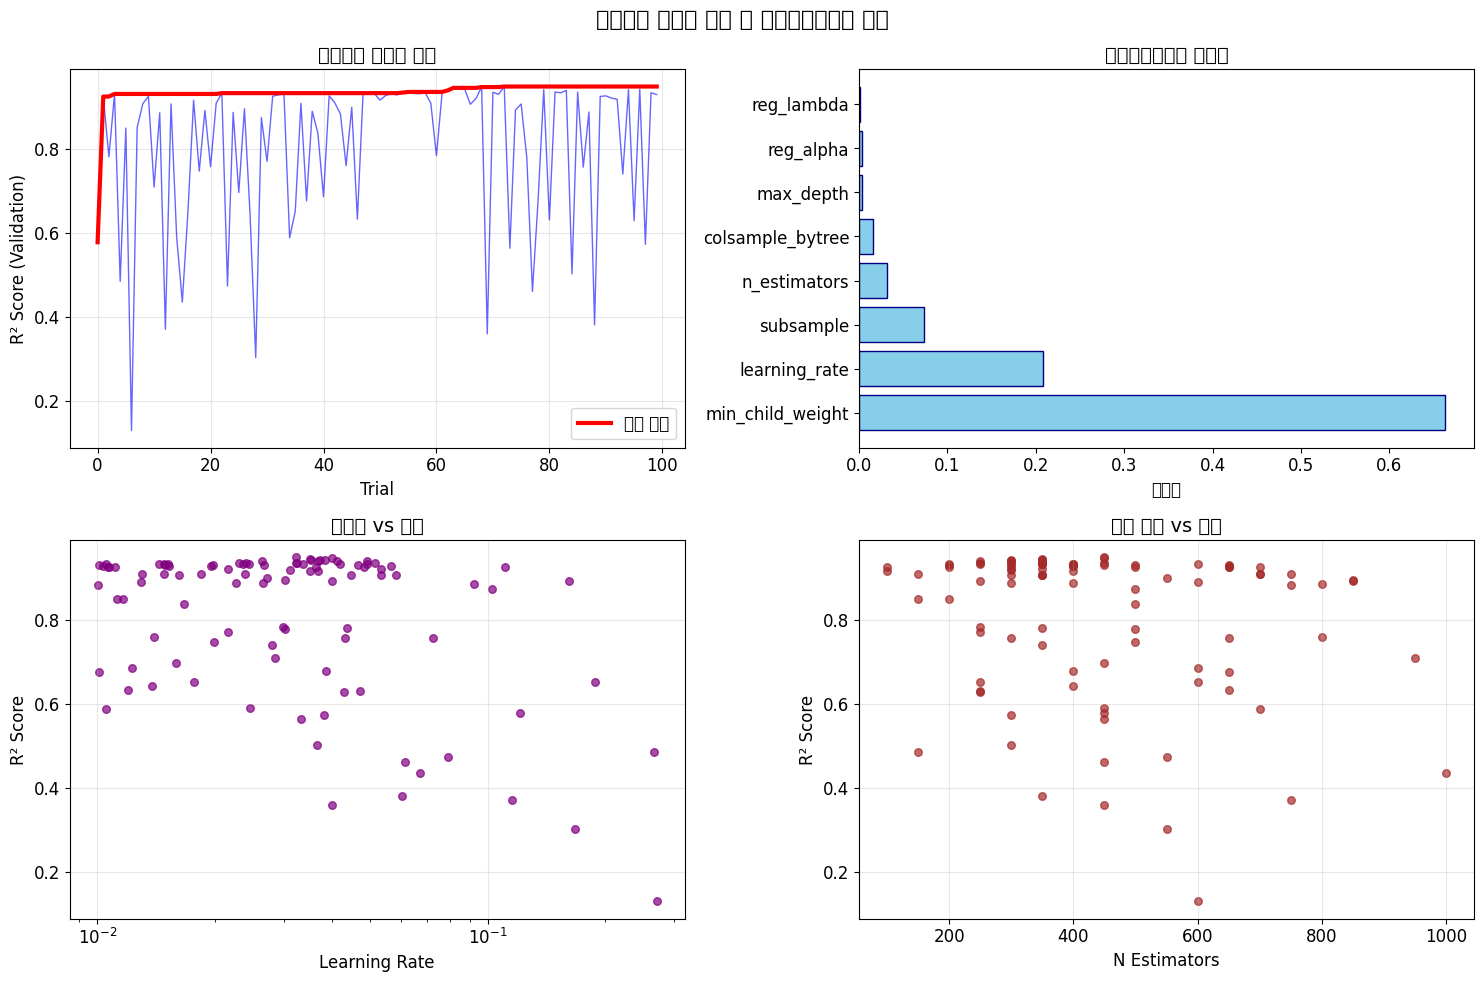

✓ 저장 완료: XGBoost_Bayesian_Optimization_PDFs/02_모델성능비교종합.pdf


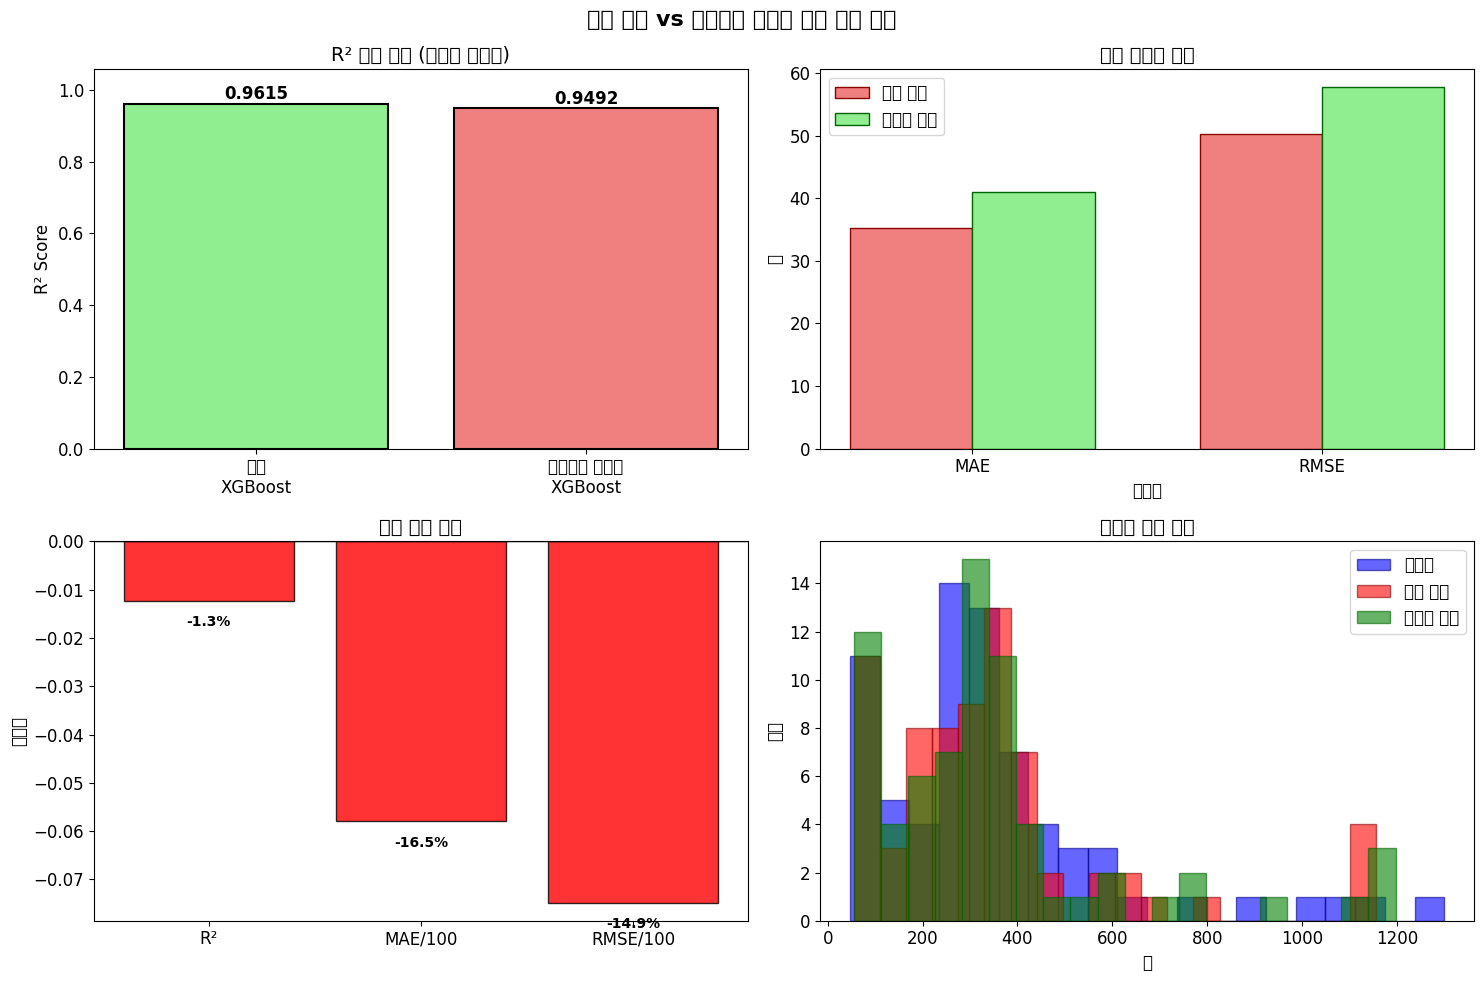

✓ 저장 완료: XGBoost_Bayesian_Optimization_PDFs/03_1대1플롯비교.pdf


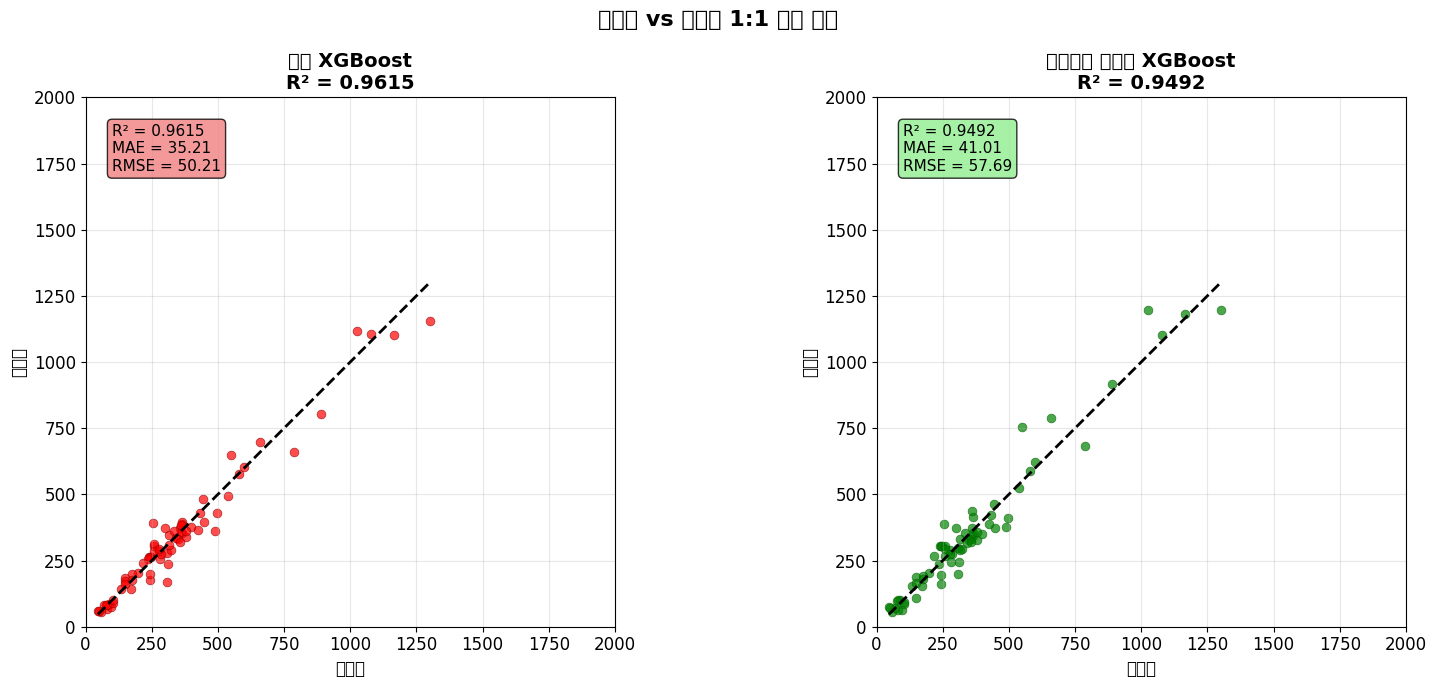

✓ 저장 완료: XGBoost_Bayesian_Optimization_PDFs/04_잔차분석_변수중요도.pdf


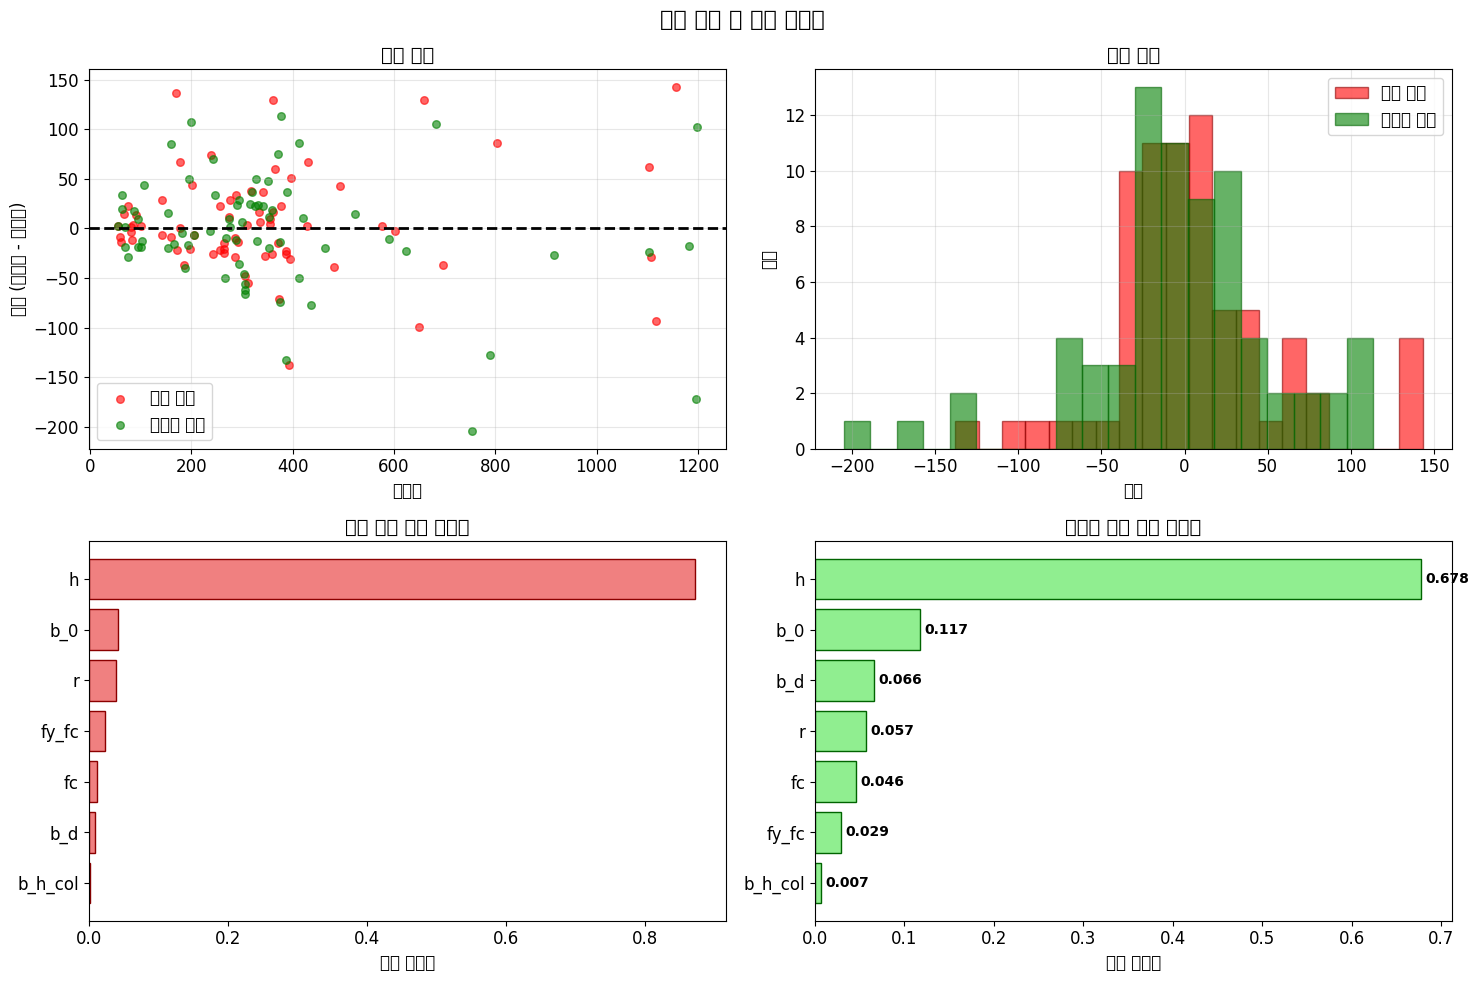

✓ 저장 완료: XGBoost_Bayesian_Optimization_PDFs/05_베이지안최적화결과_요약.txt

=== 최적화 모델 변수 중요도 ===
1. h         : 0.6778
2. b_0       : 0.1172
3. b_d       : 0.0656
4. r         : 0.0566
5. fc        : 0.0461
6. fy_fc     : 0.0294
7. b_h_col   : 0.0073

=== 최종 결과 요약 ===
• 사용된 입력변수: 7개
• 최적화 시행 횟수: 100회
• 최적화 소요 시간: 24.4초
• 기본 모델 테스트 R²: 0.9615
• 최적화 모델 테스트 R²: 0.9492
• R² 성능 개선: -0.0123 (-1.28%)
• ⚠️ 베이지안 최적화 후에도 큰 개선이 없었습니다.

=== PDF 저장 완료 ===
모든 그래프와 결과가 'XGBoost_Bayesian_Optimization_PDFs' 폴더에 저장되었습니다:
  1. 01_베이지안최적화과정.pdf
  2. 02_모델성능비교종합.pdf
  3. 03_1대1플롯비교.pdf
  4. 04_잔차분석_변수중요도.pdf
  5. 05_베이지안최적화결과_요약.txt


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
import warnings
import time
import os
warnings.filterwarnings('ignore')

# PDF 저장 폴더 생성
pdf_folder = 'XGBoost_Bayesian_Optimization_PDFs'
if not os.path.exists(pdf_folder):
    os.makedirs(pdf_folder)
    print(f"PDF 저장 폴더 생성: {pdf_folder}")

# Excel 파일 읽기
df = pd.read_excel('../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx')

# 선택된 입력 변수와 출력 변수 정의
selected_features = ['h', 'b_0', 'b_h_col', 'fc', 'r', 'fy_fc', 'b_d']
target = 'Vn'

# 데이터 준비
X = df[selected_features]
y = df[target]

print(f"데이터 형태: {X.shape}")
print(f"선택된 입력 변수: {selected_features}")
print(f"출력 변수: {target}")
print("-" * 80)

# 훈련/검증/테스트 데이터 분할 (70:15:15) - 이전과 동일한 random_state 사용
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"훈련 데이터: {X_train.shape}")
print(f"검증 데이터: {X_val.shape}")
print(f"테스트 데이터: {X_test.shape}")
print("-" * 80)

# 기본 XGBoost 모델 (비교용)
print("기본 XGBoost 모델 훈련 중...")
baseline_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"기본 모델 테스트 R²: {baseline_r2:.4f}")
print(f"기본 모델 테스트 MAE: {baseline_mae:.2f}")
print(f"기본 모델 테스트 RMSE: {baseline_rmse:.2f}")

# 베이지안 최적화를 위한 목적 함수 정의
def objective(trial):
    # 하이퍼파라미터 탐색 공간 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # XGBoost 모델 생성 및 훈련
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    # 검증 데이터로 예측 및 R² 점수 계산
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    
    return r2

print("\n" + "-" * 80)
print("베이지안 최적화 시작...")
print("목표: R² 점수 최대화")
print("-" * 80)

# Optuna Study 생성 (R² 최대화)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
)

# 최적화 시작 시간
start_time = time.time()

# 베이지안 최적화 실행 (100회 시행)
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 최적화 완료 시간
end_time = time.time()
optimization_time = end_time - start_time

print("\n" + "=" * 80)
print("=== 베이지안 최적화 완료 ===")
print("=" * 80)
print(f"최적화 시간: {optimization_time:.2f}초")
print(f"총 시행 횟수: {len(study.trials)}")
print(f"최고 R² 점수 (검증): {study.best_value:.4f}")

print("\n=== 최적 하이퍼파라미터 ===")
for param, value in study.best_params.items():
    print(f"{param:20s}: {value}")

# 최적 모델로 재훈련
print("\n" + "-" * 80)
print("최적 하이퍼파라미터로 최종 모델 훈련 중...")

optimized_model = xgb.XGBRegressor(**study.best_params)
optimized_model.fit(X_train, y_train)

# 테스트 데이터로 성능 평가
optimized_pred = optimized_model.predict(X_test)
optimized_r2 = r2_score(y_test, optimized_pred)
optimized_mae = mean_absolute_error(y_test, optimized_pred)
optimized_rmse = np.sqrt(mean_squared_error(y_test, optimized_pred))

print("\n" + "=" * 80)
print("=== 테스트 데이터 성능 비교 ===")
print("=" * 80)

# 성능 비교 테이블
comparison_df = pd.DataFrame({
    'Model': ['기본 XGBoost', '베이지안 최적화 XGBoost'],
    'R²': [baseline_r2, optimized_r2],
    'MAE': [baseline_mae, optimized_mae],
    'RMSE': [baseline_rmse, optimized_rmse]
})

print(comparison_df.round(4))

# 성능 개선 계산
r2_improvement = optimized_r2 - baseline_r2
mae_improvement = baseline_mae - optimized_mae  # MAE는 낮을수록 좋음
rmse_improvement = baseline_rmse - optimized_rmse  # RMSE도 낮을수록 좋음

print(f"\n=== 성능 개선 결과 ===")
print(f"R² 개선: {r2_improvement:+.4f} ({r2_improvement/baseline_r2*100:+.2f}%)")
print(f"MAE 개선: {mae_improvement:+.2f} ({mae_improvement/baseline_mae*100:+.2f}%)")
print(f"RMSE 개선: {rmse_improvement:+.2f} ({rmse_improvement/baseline_rmse*100:+.2f}%)")

if optimized_r2 > baseline_r2:
    print("\n✅ 베이지안 최적화를 통해 성능이 개선되었습니다!")
else:
    print("\n⚠️ 베이지안 최적화 후에도 성능이 크게 개선되지 않았습니다.")

print(f"\n그래프를 PDF로 저장 중...")

# 스타일 설정
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. 베이지안 최적화 과정 및 하이퍼파라미터 분석 (PDF 저장)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('베이지안 최적화 과정 및 하이퍼파라미터 분석', fontsize=16, fontweight='bold')

# 최적화 과정 시각화
trials_df = study.trials_dataframe()
axes[0, 0].plot(trials_df.index, trials_df['value'], 'b-', alpha=0.6, linewidth=1)
axes[0, 0].plot(trials_df.index, trials_df['value'].cummax(), 'r-', linewidth=3, label='최고 점수')
axes[0, 0].set_xlabel('Trial')
axes[0, 0].set_ylabel('R² Score (Validation)')
axes[0, 0].set_title('베이지안 최적화 과정')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 하이퍼파라미터 중요도
importance = optuna.importance.get_param_importances(study)
params = list(importance.keys())
values = list(importance.values())
axes[0, 1].barh(params, values, color='skyblue', edgecolor='navy')
axes[0, 1].set_xlabel('중요도')
axes[0, 1].set_title('하이퍼파라미터 중요도')

# 학습률 vs 성능
lr_data = [(trial.params.get('learning_rate', 0), trial.value) 
           for trial in study.trials if trial.value is not None]
if lr_data:
    lrs, values = zip(*lr_data)
    axes[1, 0].scatter(lrs, values, alpha=0.7, s=30, color='purple')
    axes[1, 0].set_xlabel('Learning Rate')
    axes[1, 0].set_ylabel('R² Score')
    axes[1, 0].set_title('학습률 vs 성능')
    axes[1, 0].set_xscale('log')
    axes[1, 0].grid(True, alpha=0.3)

# 트리 개수 vs 성능
n_est_data = [(trial.params.get('n_estimators', 0), trial.value) 
              for trial in study.trials if trial.value is not None]
if n_est_data:
    n_ests, values = zip(*n_est_data)
    axes[1, 1].scatter(n_ests, values, alpha=0.7, s=30, color='brown')
    axes[1, 1].set_xlabel('N Estimators')
    axes[1, 1].set_ylabel('R² Score')
    axes[1, 1].set_title('트리 개수 vs 성능')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{pdf_folder}/01_베이지안최적화과정.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/01_베이지안최적화과정.pdf")
plt.show()

# 2. 모델 성능 비교 종합 (PDF 저장)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('기본 모델 vs 베이지안 최적화 모델 성능 비교', fontsize=16, fontweight='bold')

# 모델 성능 비교 (R²)
models = ['기본\nXGBoost', '베이지안 최적화\nXGBoost']
r2_scores = [baseline_r2, optimized_r2]
colors = ['lightcoral', 'lightgreen'] if optimized_r2 > baseline_r2 else ['lightgreen', 'lightcoral']
bars = axes[0, 0].bar(models, r2_scores, color=colors, edgecolor='black', linewidth=1.5)

# 바 위에 값 표시
for bar, r2 in zip(bars, r2_scores):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{r2:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('R² 점수 비교 (테스트 데이터)')
axes[0, 0].set_ylim(0, max(r2_scores) * 1.1)

# MAE/RMSE 비교
metrics = ['MAE', 'RMSE']
baseline_metrics = [baseline_mae, baseline_rmse]
optimized_metrics = [optimized_mae, optimized_rmse]

x = np.arange(len(metrics))
width = 0.35

axes[0, 1].bar(x - width/2, baseline_metrics, width, label='기본 모델', 
               color='lightcoral', edgecolor='darkred', linewidth=1)
axes[0, 1].bar(x + width/2, optimized_metrics, width, label='최적화 모델', 
               color='lightgreen', edgecolor='darkgreen', linewidth=1)

axes[0, 1].set_xlabel('메트릭')
axes[0, 1].set_ylabel('값')
axes[0, 1].set_title('에러 메트릭 비교')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics)
axes[0, 1].legend()

# 성능 개선 시각화
improvements = [r2_improvement, mae_improvement/100, rmse_improvement/100]  # 스케일 조정
improvement_names = ['R²', 'MAE/100', 'RMSE/100']
colors = ['green' if imp > 0 else 'red' for imp in improvements]

bars = axes[1, 0].bar(improvement_names, improvements, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_ylabel('개선량')
axes[1, 0].set_title('성능 개선 정도')

# 바 위에 개선 퍼센트 표시
improvement_percents = [r2_improvement/baseline_r2*100, mae_improvement/baseline_mae*100, rmse_improvement/baseline_rmse*100]
for bar, imp_pct in zip(bars, improvement_percents):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.001 if bar.get_height() > 0 else -0.003),
             f'{imp_pct:+.1f}%', ha='center', va='bottom' if bar.get_height() > 0 else 'top', 
             fontweight='bold', fontsize=10)

# 예측값 분포 비교
axes[1, 1].hist(y_test, bins=20, alpha=0.6, label='실제값', color='blue', edgecolor='darkblue', linewidth=1)
axes[1, 1].hist(baseline_pred, bins=20, alpha=0.6, label='기본 모델', color='red', edgecolor='darkred', linewidth=1)
axes[1, 1].hist(optimized_pred, bins=20, alpha=0.6, label='최적화 모델', color='green', edgecolor='darkgreen', linewidth=1)
axes[1, 1].set_xlabel('값')
axes[1, 1].set_ylabel('빈도')
axes[1, 1].set_title('예측값 분포 비교')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{pdf_folder}/02_모델성능비교종합.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/02_모델성능비교종합.pdf")
plt.show()

# 3. 1:1 플롯 비교 (PDF 저장)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('실제값 vs 예측값 1:1 플롯 비교', fontsize=16, fontweight='bold')

# 기본 모델 1:1 플롯
axes[0].scatter(y_test, baseline_pred, alpha=0.7, s=40, color='red', edgecolors='darkred', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
axes[0].set_xlabel('실제값', fontsize=12)
axes[0].set_ylabel('예측값', fontsize=12)
axes[0].set_title(f'기본 XGBoost\nR² = {baseline_r2:.4f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 2000)
axes[0].set_ylim(0, 2000)
axes[0].set_aspect('equal')

# 성능 정보 박스 (기본 모델)
textstr1 = f'R² = {baseline_r2:.4f}\nMAE = {baseline_mae:.2f}\nRMSE = {baseline_rmse:.2f}'
props1 = dict(boxstyle='round', facecolor='lightcoral', alpha=0.8)
axes[0].text(0.05, 0.95, textstr1, transform=axes[0].transAxes, fontsize=11,
         verticalalignment='top', bbox=props1)

# 최적화 모델 1:1 플롯
axes[1].scatter(y_test, optimized_pred, alpha=0.7, s=40, color='green', edgecolors='darkgreen', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
axes[1].set_xlabel('실제값', fontsize=12)
axes[1].set_ylabel('예측값', fontsize=12)
axes[1].set_title(f'베이지안 최적화 XGBoost\nR² = {optimized_r2:.4f}', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 2000)
axes[1].set_ylim(0, 2000)
axes[1].set_aspect('equal')

# 성능 정보 박스 (최적화 모델)
textstr2 = f'R² = {optimized_r2:.4f}\nMAE = {optimized_mae:.2f}\nRMSE = {optimized_rmse:.2f}'
props2 = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
axes[1].text(0.05, 0.95, textstr2, transform=axes[1].transAxes, fontsize=11,
         verticalalignment='top', bbox=props2)

plt.tight_layout()
plt.savefig(f'{pdf_folder}/03_1대1플롯비교.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/03_1대1플롯비교.pdf")
plt.show()

# 4. 잔차 분석 및 변수 중요도 (PDF 저장)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('잔차 분석 및 변수 중요도', fontsize=16, fontweight='bold')

# 잔차 비교
baseline_residuals = y_test - baseline_pred
optimized_residuals = y_test - optimized_pred
axes[0, 0].scatter(baseline_pred, baseline_residuals, alpha=0.6, s=30, color='red', label='기본 모델')
axes[0, 0].scatter(optimized_pred, optimized_residuals, alpha=0.6, s=30, color='green', label='최적화 모델')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('예측값')
axes[0, 0].set_ylabel('잔차 (실제값 - 예측값)')
axes[0, 0].set_title('잔차 비교')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 잔차 히스토그램
axes[0, 1].hist(baseline_residuals, bins=20, alpha=0.6, label='기본 모델', color='red', edgecolor='darkred')
axes[0, 1].hist(optimized_residuals, bins=20, alpha=0.6, label='최적화 모델', color='green', edgecolor='darkgreen')
axes[0, 1].set_xlabel('잔차')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].set_title('잔차 분포')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 기본 모델 변수 중요도
baseline_importance = baseline_model.feature_importances_
baseline_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': baseline_importance
}).sort_values('importance', ascending=True)

axes[1, 0].barh(baseline_importance_df['feature'], baseline_importance_df['importance'], 
                color='lightcoral', edgecolor='darkred', linewidth=1)
axes[1, 0].set_xlabel('변수 중요도')
axes[1, 0].set_title('기본 모델 변수 중요도')

# 최적화 모델 변수 중요도
optimized_importance = optimized_model.feature_importances_
optimized_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': optimized_importance
}).sort_values('importance', ascending=True)

bars = axes[1, 1].barh(optimized_importance_df['feature'], optimized_importance_df['importance'], 
                       color='lightgreen', edgecolor='darkgreen', linewidth=1)
axes[1, 1].set_xlabel('변수 중요도')
axes[1, 1].set_title('최적화 모델 변수 중요도')

# 중요도 값을 막대 끝에 표시
for i, (_, row) in enumerate(optimized_importance_df.iterrows()):
    axes[1, 1].text(row['importance'] + 0.005, i, f'{row["importance"]:.3f}', 
             va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{pdf_folder}/04_잔차분석_변수중요도.pdf', dpi=300, bbox_inches='tight')
print(f"✓ 저장 완료: {pdf_folder}/04_잔차분석_변수중요도.pdf")
plt.show()

# 결과 요약을 텍스트 파일로 저장
with open(f'{pdf_folder}/05_베이지안최적화결과_요약.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("XGBoost 베이지안 최적화 결과 요약\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"사용된 입력변수: {selected_features}\n")
    f.write(f"최적화 시간: {optimization_time:.2f}초\n")
    f.write(f"최적화 시행 횟수: {len(study.trials)}회\n")
    f.write(f"최고 R² 점수 (검증): {study.best_value:.4f}\n\n")
    
    f.write("최적 하이퍼파라미터:\n")
    f.write("-" * 40 + "\n")
    for param, value in study.best_params.items():
        f.write(f"{param:20s}: {value}\n")
    
    f.write(f"\n테스트 데이터 성능 비교:\n")
    f.write("-" * 40 + "\n")
    f.write(f"기본 XGBoost:\n")
    f.write(f"  R²: {baseline_r2:.4f}\n")
    f.write(f"  MAE: {baseline_mae:.2f}\n")
    f.write(f"  RMSE: {baseline_rmse:.2f}\n\n")
    
    f.write(f"베이지안 최적화 XGBoost:\n")
    f.write(f"  R²: {optimized_r2:.4f}\n")
    f.write(f"  MAE: {optimized_mae:.2f}\n")
    f.write(f"  RMSE: {optimized_rmse:.2f}\n\n")
    
    f.write(f"성능 개선:\n")
    f.write("-" * 40 + "\n")
    f.write(f"R² 개선: {r2_improvement:+.4f} ({r2_improvement/baseline_r2*100:+.2f}%)\n")
    f.write(f"MAE 개선: {mae_improvement:+.2f} ({mae_improvement/baseline_mae*100:+.2f}%)\n")
    f.write(f"RMSE 개선: {rmse_improvement:+.2f} ({rmse_improvement/baseline_rmse*100:+.2f}%)\n\n")
    
    f.write(f"최적화 모델 변수 중요도:\n")
    f.write("-" * 40 + "\n")
    optimized_importance_sorted = optimized_importance_df.sort_values('importance', ascending=False)
    for i, (_, row) in enumerate(optimized_importance_sorted.iterrows(), 1):
        f.write(f"{i}. {row['feature']:10s}: {row['importance']:.4f}\n")

print(f"✓ 저장 완료: {pdf_folder}/05_베이지안최적화결과_요약.txt")

print("\n" + "=" * 80)
print("=== 최적화 모델 변수 중요도 ===")
print("=" * 80)
optimized_importance_sorted = optimized_importance_df.sort_values('importance', ascending=False)
for i, (_, row) in enumerate(optimized_importance_sorted.iterrows(), 1):
    print(f"{i}. {row['feature']:10s}: {row['importance']:.4f}")

print("\n" + "=" * 80)
print("=== 최종 결과 요약 ===")
print("=" * 80)
print(f"• 사용된 입력변수: {len(selected_features)}개")
print(f"• 최적화 시행 횟수: {len(study.trials)}회")
print(f"• 최적화 소요 시간: {optimization_time:.1f}초")
print(f"• 기본 모델 테스트 R²: {baseline_r2:.4f}")
print(f"• 최적화 모델 테스트 R²: {optimized_r2:.4f}")
print(f"• R² 성능 개선: {r2_improvement:+.4f} ({r2_improvement/baseline_r2*100:+.2f}%)")

if optimized_r2 > baseline_r2:
    print(f"• ✅ 베이지안 최적화를 통해 성능이 향상되었습니다!")
else:
    print(f"• ⚠️ 베이지안 최적화 후에도 큰 개선이 없었습니다.")

print("\n" + "=" * 80)
print("=== PDF 저장 완료 ===")
print("=" * 80)
print(f"모든 그래프와 결과가 '{pdf_folder}' 폴더에 저장되었습니다:")
print(f"  1. 01_베이지안최적화과정.pdf")
print(f"  2. 02_모델성능비교종합.pdf")
print(f"  3. 03_1대1플롯비교.pdf")
print(f"  4. 04_잔차분석_변수중요도.pdf")
print(f"  5. 05_베이지안최적화결과_요약.txt")
print("=" * 80)

[I 2025-08-28 13:59:47,507] A new study created in memory with name: no-name-e730ee78-fa1f-4d80-afd9-8f84eaff0dc2


데이터 형태: (472, 7)
선택된 입력 변수: ['h', 'b_0', 'b_h_col', 'fc', 'r', 'fy_fc', 'b_d']
출력 변수: Vn
--------------------------------------------------------------------------------
훈련 데이터: (330, 7)
검증 데이터: (71, 7)
테스트 데이터: (71, 7)
--------------------------------------------------------------------------------
기본 XGBoost 모델 훈련 중...
기본 모델 테스트 R²: 0.9615
기본 모델 테스트 MAE: 35.21
기본 모델 테스트 RMSE: 50.21

--------------------------------------------------------------------------------
베이지안 최적화 시작...
목표: R² 점수 최대화
--------------------------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-08-28 13:59:47,889] Trial 0 finished with value: 0.5771921873092651 and parameters: {'n_estimators': 450, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9}. Best is trial 0 with value: 0.5771921873092651.
[I 2025-08-28 13:59:48,564] Trial 1 finished with value: 0.9239779710769653 and parameters: {'n_estimators': 650, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'reg_alpha': 8.148018307012941e-07, 'reg_lambda': 4.329370014459266e-07, 'min_child_weight': 2}. Best is trial 1 with value: 0.9239779710769653.
[I 2025-08-28 13:59:48,826] Trial 2 finished with value: 0.7805914878845215 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8

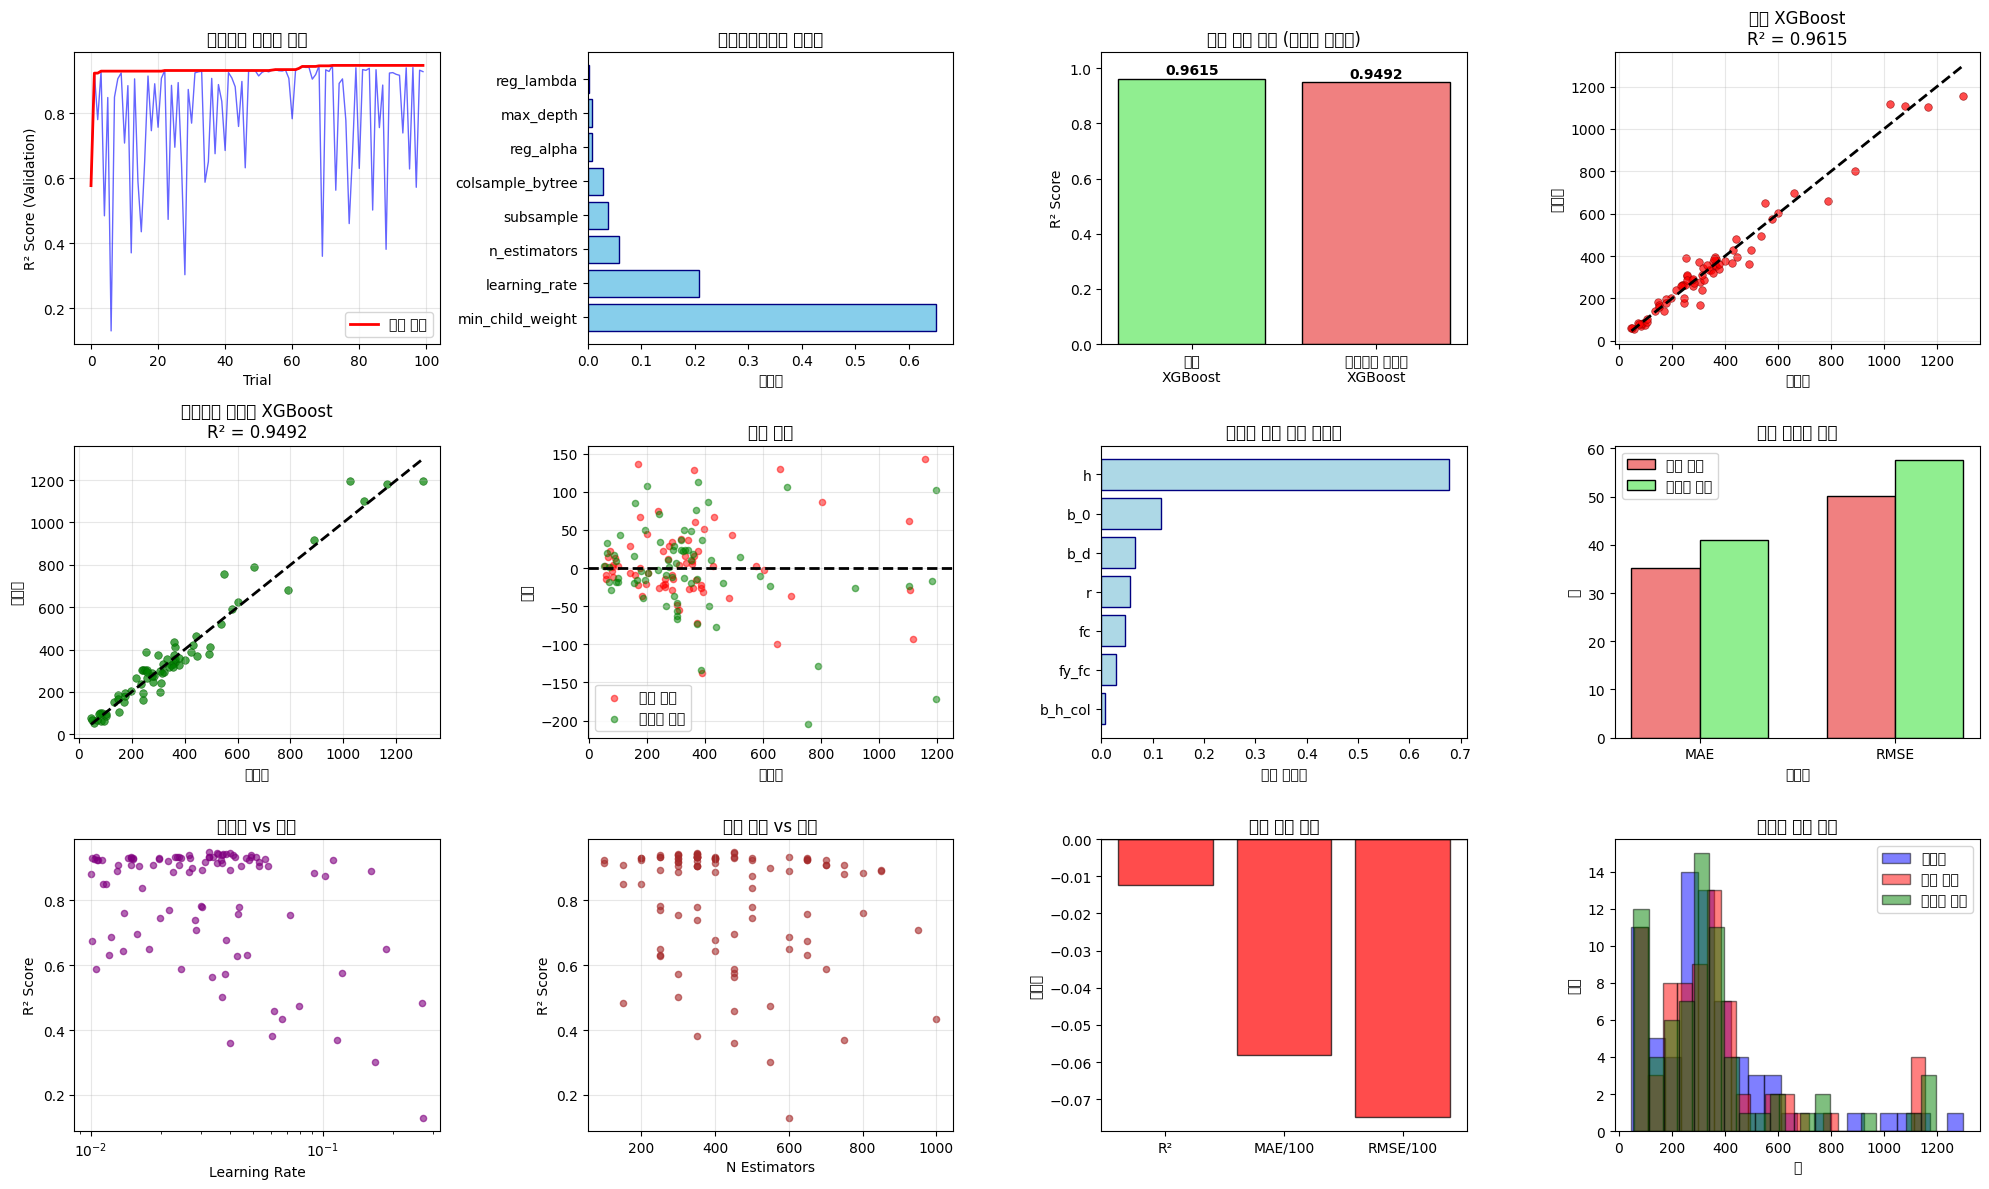


=== 최적화 모델 변수 중요도 ===
1. b_h_col   : 0.0073
2. fy_fc     : 0.0294
3. fc        : 0.0461
4. r         : 0.0566
5. b_d       : 0.0656
6. b_0       : 0.1172
7. h         : 0.6778

=== 최종 결과 요약 ===
• 사용된 입력변수: 7개
• 최적화 시행 횟수: 100회
• 최적화 소요 시간: 23.1초
• 기본 모델 테스트 R²: 0.9615
• 최적화 모델 테스트 R²: 0.9492
• R² 성능 개선: -0.0123 (-1.28%)
• ⚠️ 베이지안 최적화 후에도 큰 개선이 없었습니다.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
import warnings
import time
warnings.filterwarnings('ignore')

# Excel 파일 읽기
df = pd.read_excel('../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx')

# 선택된 입력 변수와 출력 변수 정의
selected_features = ['h', 'b_0', 'b_h_col', 'fc', 'r', 'fy_fc', 'b_d']
target = 'Vn'

# 데이터 준비
X = df[selected_features]
y = df[target]

print(f"데이터 형태: {X.shape}")
print(f"선택된 입력 변수: {selected_features}")
print(f"출력 변수: {target}")
print("-" * 80)

# 훈련/검증/테스트 데이터 분할 (70:15:15) - 이전과 동일한 random_state 사용
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"훈련 데이터: {X_train.shape}")
print(f"검증 데이터: {X_val.shape}")
print(f"테스트 데이터: {X_test.shape}")
print("-" * 80)

# 기본 XGBoost 모델 (비교용)
print("기본 XGBoost 모델 훈련 중...")
baseline_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"기본 모델 테스트 R²: {baseline_r2:.4f}")
print(f"기본 모델 테스트 MAE: {baseline_mae:.2f}")
print(f"기본 모델 테스트 RMSE: {baseline_rmse:.2f}")

# 베이지안 최적화를 위한 목적 함수 정의
def objective(trial):
    # 하이퍼파라미터 탐색 공간 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # XGBoost 모델 생성 및 훈련
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    # 검증 데이터로 예측 및 R² 점수 계산
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    
    return r2

print("\n" + "-" * 80)
print("베이지안 최적화 시작...")
print("목표: R² 점수 최대화")
print("-" * 80)

# Optuna Study 생성 (R² 최대화)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
)

# 최적화 시작 시간
start_time = time.time()

# 베이지안 최적화 실행 (100회 시행)
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 최적화 완료 시간
end_time = time.time()
optimization_time = end_time - start_time

print("\n" + "=" * 80)
print("=== 베이지안 최적화 완료 ===")
print("=" * 80)
print(f"최적화 시간: {optimization_time:.2f}초")
print(f"총 시행 횟수: {len(study.trials)}")
print(f"최고 R² 점수 (검증): {study.best_value:.4f}")

print("\n=== 최적 하이퍼파라미터 ===")
for param, value in study.best_params.items():
    print(f"{param:20s}: {value}")

# 최적 모델로 재훈련
print("\n" + "-" * 80)
print("최적 하이퍼파라미터로 최종 모델 훈련 중...")

optimized_model = xgb.XGBRegressor(**study.best_params)
optimized_model.fit(X_train, y_train)

# 테스트 데이터로 성능 평가
optimized_pred = optimized_model.predict(X_test)
optimized_r2 = r2_score(y_test, optimized_pred)
optimized_mae = mean_absolute_error(y_test, optimized_pred)
optimized_rmse = np.sqrt(mean_squared_error(y_test, optimized_pred))

print("\n" + "=" * 80)
print("=== 테스트 데이터 성능 비교 ===")
print("=" * 80)

# 성능 비교 테이블
comparison_df = pd.DataFrame({
    'Model': ['기본 XGBoost', '베이지안 최적화 XGBoost'],
    'R²': [baseline_r2, optimized_r2],
    'MAE': [baseline_mae, optimized_mae],
    'RMSE': [baseline_rmse, optimized_rmse]
})

print(comparison_df.round(4))

# 성능 개선 계산
r2_improvement = optimized_r2 - baseline_r2
mae_improvement = baseline_mae - optimized_mae  # MAE는 낮을수록 좋음
rmse_improvement = baseline_rmse - optimized_rmse  # RMSE도 낮을수록 좋음

print(f"\n=== 성능 개선 결과 ===")
print(f"R² 개선: {r2_improvement:+.4f} ({r2_improvement/baseline_r2*100:+.2f}%)")
print(f"MAE 개선: {mae_improvement:+.2f} ({mae_improvement/baseline_mae*100:+.2f}%)")
print(f"RMSE 개선: {rmse_improvement:+.2f} ({rmse_improvement/baseline_rmse*100:+.2f}%)")

if optimized_r2 > baseline_r2:
    print("\n✅ 베이지안 최적화를 통해 성능이 개선되었습니다!")
else:
    print("\n⚠️ 베이지안 최적화 후에도 성능이 크게 개선되지 않았습니다.")

# 시각화
plt.style.use('default')
fig = plt.figure(figsize=(20, 12))

# 1. 최적화 과정 시각화
plt.subplot(3, 4, 1)
trials_df = study.trials_dataframe()
plt.plot(trials_df.index, trials_df['value'], 'b-', alpha=0.6, linewidth=1)
plt.plot(trials_df.index, trials_df['value'].cummax(), 'r-', linewidth=2, label='최고 점수')
plt.xlabel('Trial')
plt.ylabel('R² Score (Validation)')
plt.title('베이지안 최적화 과정')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 하이퍼파라미터 중요도
plt.subplot(3, 4, 2)
importance = optuna.importance.get_param_importances(study)
params = list(importance.keys())
values = list(importance.values())
plt.barh(params, values, color='skyblue', edgecolor='navy')
plt.xlabel('중요도')
plt.title('하이퍼파라미터 중요도')

# 3. 모델 성능 비교 (R²)
plt.subplot(3, 4, 3)
models = ['기본\nXGBoost', '베이지안 최적화\nXGBoost']
r2_scores = [baseline_r2, optimized_r2]
colors = ['lightcoral', 'lightgreen'] if optimized_r2 > baseline_r2 else ['lightgreen', 'lightcoral']
bars = plt.bar(models, r2_scores, color=colors, edgecolor='black', linewidth=1)

# 바 위에 값 표시
for bar, r2 in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{r2:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('R² Score')
plt.title('모델 성능 비교 (테스트 데이터)')
plt.ylim(0, max(r2_scores) * 1.1)

# 4. 1:1 플롯 비교 (기본 모델)
plt.subplot(3, 4, 4)
plt.scatter(y_test, baseline_pred, alpha=0.7, s=30, color='red', edgecolors='darkred', linewidth=0.5, label='기본 모델')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title(f'기본 XGBoost\nR² = {baseline_r2:.4f}')
plt.grid(True, alpha=0.3)

# 5. 1:1 플롯 (최적화 모델)
plt.subplot(3, 4, 5)
plt.scatter(y_test, optimized_pred, alpha=0.7, s=30, color='green', edgecolors='darkgreen', linewidth=0.5, label='최적화 모델')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title(f'베이지안 최적화 XGBoost\nR² = {optimized_r2:.4f}')
plt.grid(True, alpha=0.3)

# 6. 잔차 비교
plt.subplot(3, 4, 6)
baseline_residuals = y_test - baseline_pred
optimized_residuals = y_test - optimized_pred
plt.scatter(baseline_pred, baseline_residuals, alpha=0.5, s=20, color='red', label='기본 모델')
plt.scatter(optimized_pred, optimized_residuals, alpha=0.5, s=20, color='green', label='최적화 모델')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.xlabel('예측값')
plt.ylabel('잔차')
plt.title('잔차 비교')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. 변수 중요도 (최적화 모델)
plt.subplot(3, 4, 7)
feature_importance = optimized_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

plt.barh(importance_df['feature'], importance_df['importance'], color='lightblue', edgecolor='navy')
plt.xlabel('변수 중요도')
plt.title('최적화 모델 변수 중요도')

# 8. MAE/RMSE 비교
plt.subplot(3, 4, 8)
metrics = ['MAE', 'RMSE']
baseline_metrics = [baseline_mae, baseline_rmse]
optimized_metrics = [optimized_mae, optimized_rmse]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_metrics, width, label='기본 모델', color='lightcoral', edgecolor='black')
plt.bar(x + width/2, optimized_metrics, width, label='최적화 모델', color='lightgreen', edgecolor='black')

plt.xlabel('메트릭')
plt.ylabel('값')
plt.title('에러 메트릭 비교')
plt.xticks(x, metrics)
plt.legend()

# 9. 학습률 vs 성능
plt.subplot(3, 4, 9)
lr_data = [(trial.params.get('learning_rate', 0), trial.value) 
           for trial in study.trials if trial.value is not None]
if lr_data:
    lrs, values = zip(*lr_data)
    plt.scatter(lrs, values, alpha=0.6, s=20, color='purple')
    plt.xlabel('Learning Rate')
    plt.ylabel('R² Score')
    plt.title('학습률 vs 성능')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)

# 10. 트리 개수 vs 성능
plt.subplot(3, 4, 10)
n_est_data = [(trial.params.get('n_estimators', 0), trial.value) 
              for trial in study.trials if trial.value is not None]
if n_est_data:
    n_ests, values = zip(*n_est_data)
    plt.scatter(n_ests, values, alpha=0.6, s=20, color='brown')
    plt.xlabel('N Estimators')
    plt.ylabel('R² Score')
    plt.title('트리 개수 vs 성능')
    plt.grid(True, alpha=0.3)

# 11. 성능 개선 시각화
plt.subplot(3, 4, 11)
improvements = [r2_improvement, mae_improvement/100, rmse_improvement/100]  # 스케일 조정
improvement_names = ['R²', 'MAE/100', 'RMSE/100']
colors = ['green' if imp > 0 else 'red' for imp in improvements]

bars = plt.bar(improvement_names, improvements, color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.ylabel('개선량')
plt.title('성능 개선 정도')

# 12. 예측값 분포 비교
plt.subplot(3, 4, 12)
plt.hist(y_test, bins=20, alpha=0.5, label='실제값', color='blue', edgecolor='black')
plt.hist(baseline_pred, bins=20, alpha=0.5, label='기본 모델', color='red', edgecolor='black')
plt.hist(optimized_pred, bins=20, alpha=0.5, label='최적화 모델', color='green', edgecolor='black')
plt.xlabel('값')
plt.ylabel('빈도')
plt.title('예측값 분포 비교')
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("=== 최적화 모델 변수 중요도 ===")
print("=" * 80)
for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"{i}. {row['feature']:10s}: {row['importance']:.4f}")

print("\n" + "=" * 80)
print("=== 최종 결과 요약 ===")
print("=" * 80)
print(f"• 사용된 입력변수: {len(selected_features)}개")
print(f"• 최적화 시행 횟수: {len(study.trials)}회")
print(f"• 최적화 소요 시간: {optimization_time:.1f}초")
print(f"• 기본 모델 테스트 R²: {baseline_r2:.4f}")
print(f"• 최적화 모델 테스트 R²: {optimized_r2:.4f}")
print(f"• R² 성능 개선: {r2_improvement:+.4f} ({r2_improvement/baseline_r2*100:+.2f}%)")

if optimized_r2 > baseline_r2:
    print(f"• ✅ 베이지안 최적화를 통해 성능이 향상되었습니다!")
else:
    print(f"• ⚠️ 베이지안 최적화 후에도 큰 개선이 없었습니다.")

데이터 형태: (472, 7)
입력 변수: ['h', 'b_0', 'b_h_col', 'fc', 'r', 'fy_fc', 'b_d']
출력 변수: Vn
------------------------------------------------------------
훈련 데이터: (377, 7)
테스트 데이터: (95, 7)
------------------------------------------------------------
XGBoost 기본 모델 훈련 중...
=== 테스트 데이터 성능 ===
R² 점수: 0.9547
MAE (평균절대오차): 34.66
RMSE (평균제곱근오차): 55.60
------------------------------------------------------------


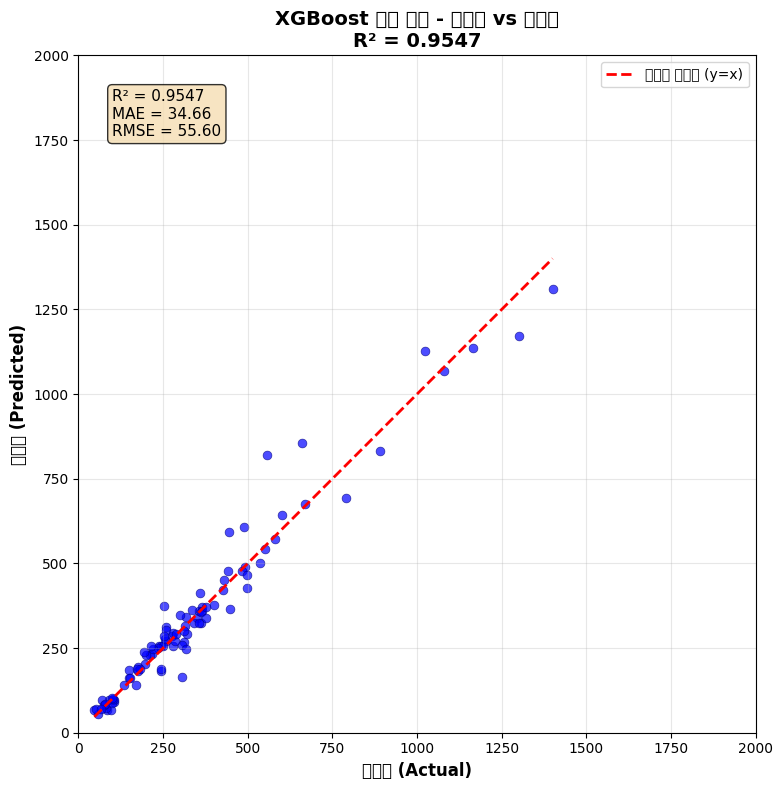

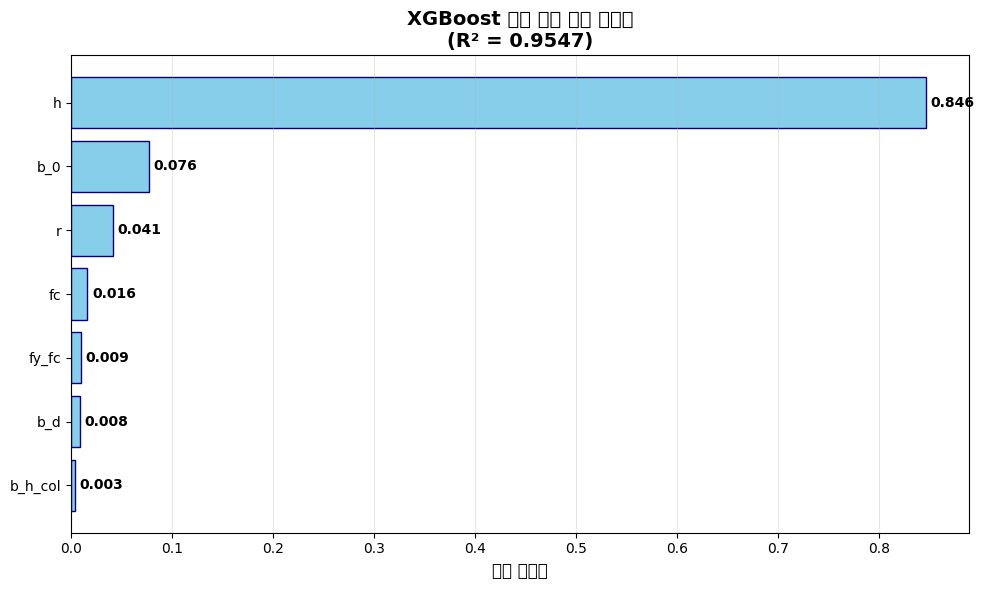

=== 변수 중요도 ===
1. h         : 0.8461
2. b_0       : 0.0765
3. r         : 0.0409
4. fc        : 0.0159
5. fy_fc     : 0.0093
6. b_d       : 0.0082
7. b_h_col   : 0.0031

최종 모델 테스트 R² 점수: 0.9547


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Excel 파일 읽기
df = pd.read_excel('../데이터 베이스/2. 12개 입력값 머신러닝 전단파괴만.xlsx')

# 입력 변수와 출력 변수 정의
input_features = ['h', 'b_0', 'b_h_col', 'fc', 'r', 'fy_fc', 'b_d']
target = 'Vn'

# 데이터 준비
X = df[input_features]
y = df[target]

print(f"데이터 형태: {X.shape}")
print(f"입력 변수: {input_features}")
print(f"출력 변수: {target}")
print("-" * 60)

# 훈련/테스트 데이터 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"훈련 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print("-" * 60)

# XGBoost 기본 모델 훈련
print("XGBoost 기본 모델 훈련 중...")
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = model.predict(X_test)

# 성능 지표 계산
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== 테스트 데이터 성능 ===")
print(f"R² 점수: {r2:.4f}")
print(f"MAE (평균절대오차): {mae:.2f}")
print(f"RMSE (평균제곱근오차): {rmse:.2f}")
print("-" * 60)

# 1:1 플롯 그리기
plt.figure(figsize=(10, 8))

# 산점도
plt.scatter(y_test, y_pred, alpha=0.7, s=40, color='blue', edgecolors='navy', linewidth=0.5)

# 완벽한 예측선 (y=x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='완벽한 예측선 (y=x)')

# 그래프 설정
plt.xlabel('실제값 (Actual)', fontsize=12, fontweight='bold')
plt.ylabel('예측값 (Predicted)', fontsize=12, fontweight='bold')
plt.title(f'XGBoost 기본 모델 - 실제값 vs 예측값\nR² = {r2:.4f}', fontsize=14, fontweight='bold')

# 축 범위 설정
plt.xlim(0, 2000)
plt.ylim(0, 2000)

# 격자 및 범례
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# 축 비율을 같게 설정
plt.gca().set_aspect('equal', adjustable='box')

# 텍스트 박스로 성능 지표 표시
textstr = f'R² = {r2:.4f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# 변수 중요도 시각화
plt.figure(figsize=(10, 6))

feature_importance = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': input_features,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

plt.barh(importance_df['feature'], importance_df['importance'], 
         color='skyblue', edgecolor='navy', linewidth=1)
plt.xlabel('변수 중요도', fontsize=12, fontweight='bold')
plt.title(f'XGBoost 기본 모델 변수 중요도\n(R² = {r2:.4f})', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# 중요도 값을 막대 끝에 표시
for i, (_, row) in enumerate(importance_df.iterrows()):
    plt.text(row['importance'] + 0.005, i, f'{row["importance"]:.3f}', 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("=== 변수 중요도 ===")
importance_df_sorted = importance_df.sort_values('importance', ascending=False)
for i, (_, row) in enumerate(importance_df_sorted.iterrows(), 1):
    print(f"{i}. {row['feature']:10s}: {row['importance']:.4f}")

print(f"\n최종 모델 테스트 R² 점수: {r2:.4f}")

### Table 3 Summary prediction results of resistance in training set and test set.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 데이터 불러오기: 엑셀 파일에서 데이터를 읽어옵니다.
file_path = "../데이터 베이스/머신러닝 데이터.xlsx"
data = pd.read_excel(file_path)

# 2. 예측에 사용할 특징(Feature)와 타깃(Target) 변수 설정
features = [
    "Shape",
    "Column_area",
    "slab's_effective_depth",
    "fc",
    "fy",
    "reinforcement_ratio",
    "FM",
]
target = "Pu"

X = data[features]
y = data[target]

# 3. 학습 데이터와 테스트 데이터로 분리 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 모델 리스트 정의
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Gradient Boost": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42, objective="reg:squarederror"),
}

# 5. 각 모델별 평가 지표 계산 (Train/Test RMSE, MAE, R²)
results = []

for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)
    # 예측 수행
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 학습 데이터 평가 지표
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # 테스트 데이터 평가 지표
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # 결과 저장
    results.append(
        {
            "Model": name,
            "Train RMSE": rmse_train,
            "Train MAE": mae_train,
            "Train R²": r2_train,
            "Test RMSE": rmse_test,
            "Test MAE": mae_test,
            "Test R²": r2_test,
        }
    )

# 6. 결과를 DataFrame으로 정리하여 출력
results_df = pd.DataFrame(results)
print(results_df)

               Model  Train RMSE   Train MAE  Train R²   Test RMSE  \
0  Linear Regression  152.815202  102.432926  0.860388  134.198110   
1      Decision Tree   14.903160    1.659314  0.998672  144.137224   
2                SVR  412.080343  186.017325 -0.015206  375.466141   
3      Random Forest   75.447341   23.202589  0.965969   84.920622   
4           AdaBoost   93.239931   73.350556  0.948025  122.237259   
5     Gradient Boost   37.557165   25.417137  0.991567  106.593363   
6            XGBoost   15.059650    3.123513  0.998644  151.819093   

     Test MAE   Test R²  
0  106.566748  0.872936  
1   69.088235  0.853417  
2  179.095307  0.005345  
3   49.120248  0.949119  
4   88.916957  0.894576  
5   55.291616  0.919834  
6   60.709904  0.837376  


### Fig.6. Prediction results of resistance in training set

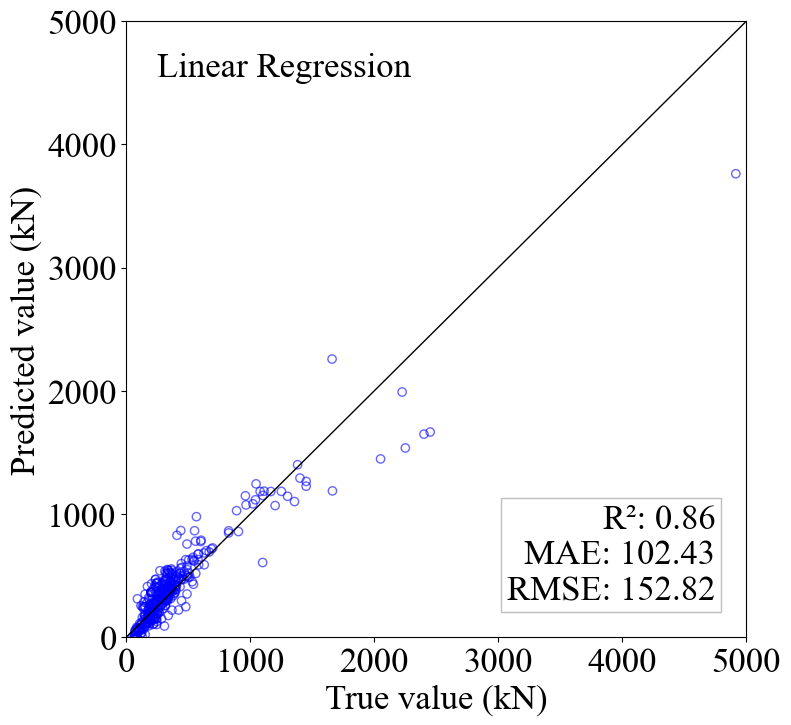

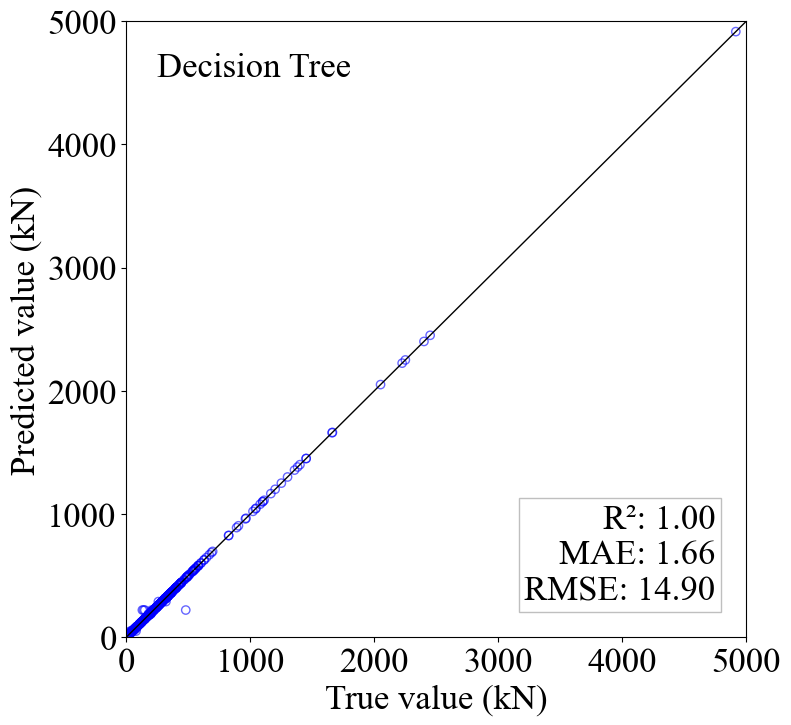

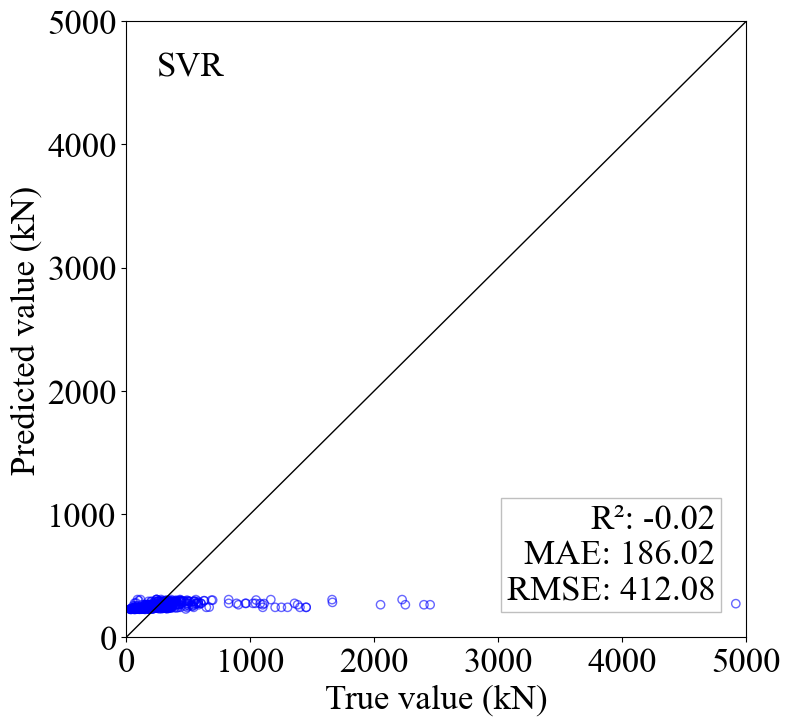

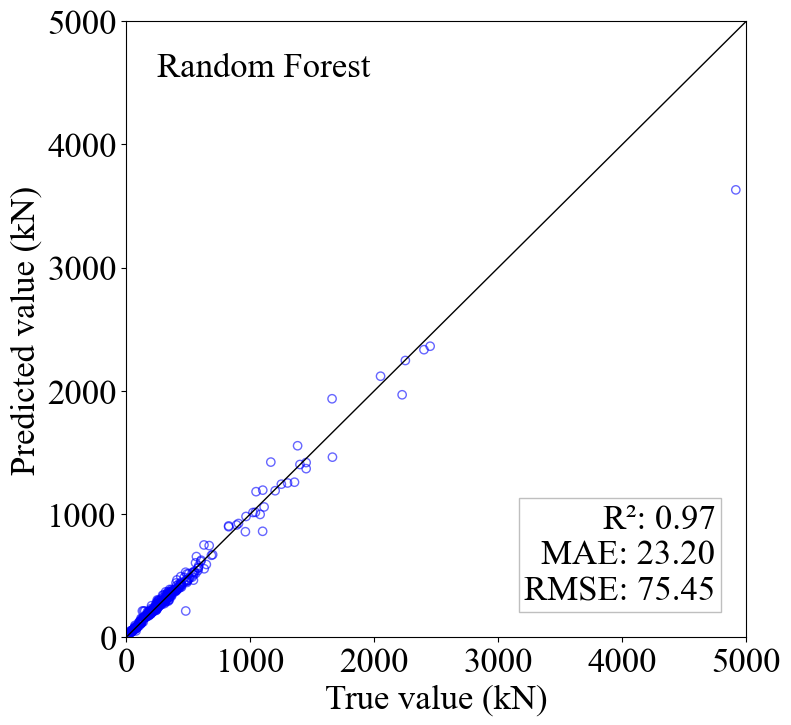

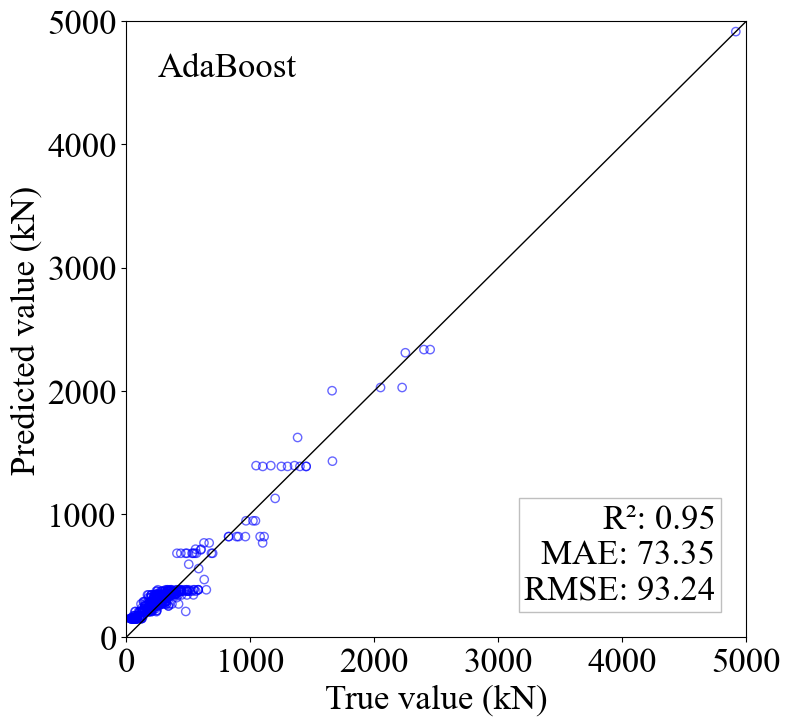

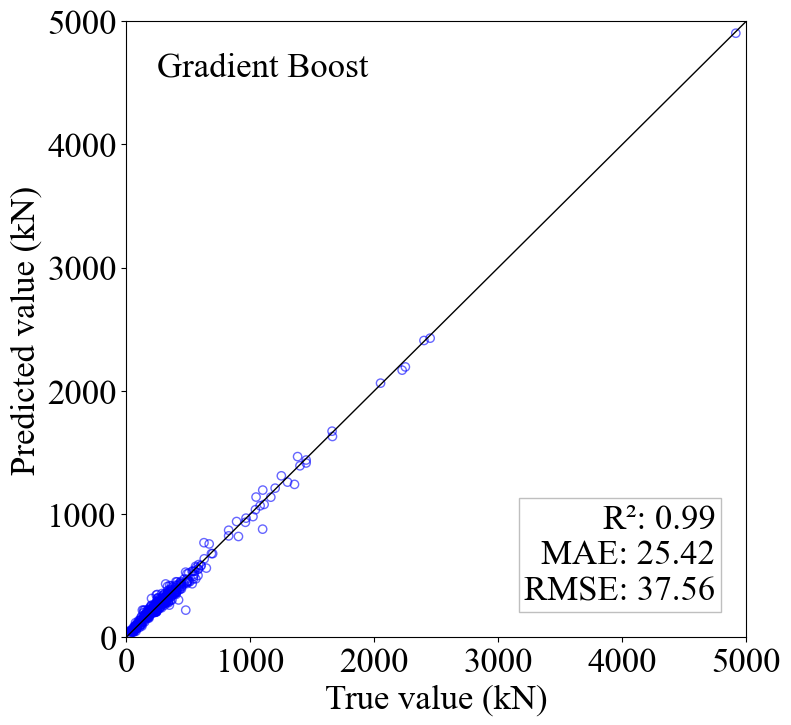

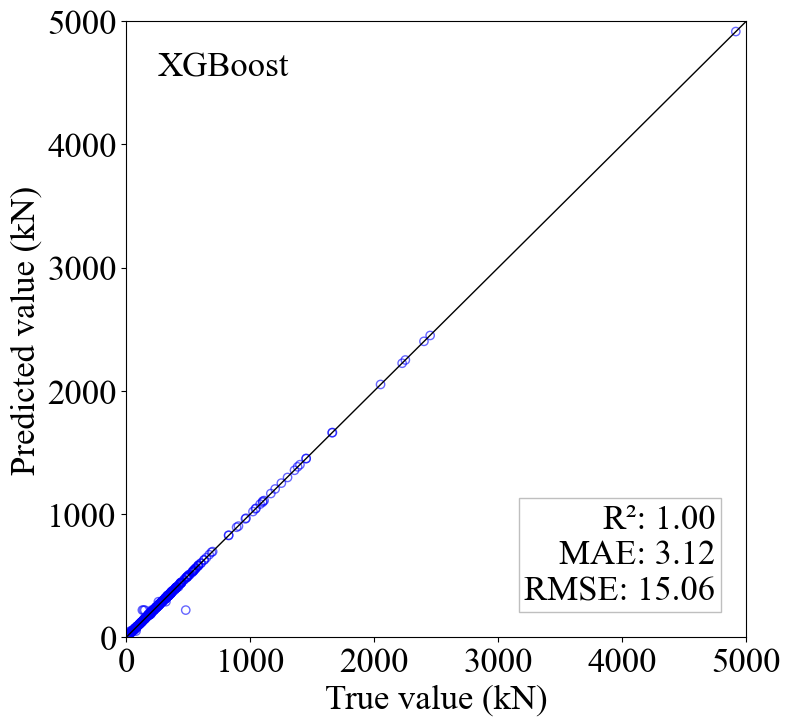

In [25]:
import matplotlib.pyplot as plt

plt.style.use("default")

# 전체 폰트 설정: Times New Roman, 14포인트
font_size = 25
plt.rc("font", family="Times New Roman", size=font_size)

# 각 모델에 대해 1:1 비교 그래프 그리기
for name, model in models.items():
    # 학습 데이터에 대한 예측 수행
    y_train_pred = model.predict(X_train)

    # 평가 지표 계산 (학습 데이터)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # 산점도 및 1:1 선 그리기
    plt.figure(figsize=(8, 8))
    # 파란색 비어있는 동그라미로 표시
    plt.scatter(
        y_train,
        y_train_pred,
        alpha=0.6,
        marker="o",
        facecolors="none",
        edgecolors="blue",
    )

    # 1:1 비교 선 (대각선)
    min_val = 0
    max_val = 5000
    plt.plot([min_val, max_val], [min_val, max_val], "black", lw=1)

    plt.xlabel("True value (kN)")
    plt.ylabel("Predicted value (kN)")

    # x축과 y축 범위를 0에서 5000으로 설정
    plt.xlim(0, 5000)
    plt.ylim(0, 5000)

    # 왼쪽 상단에 모델 이름 표기 (axes 좌표: 0~1)
    plt.text(
        0.05,
        0.95,
        name,
        transform=plt.gca().transAxes,
        fontsize=font_size,
        verticalalignment="top",
    )

    # 오른쪽 하단에 평가 지표 표기
    metrics_text = f"R²: {r2_train:.2f}\nMAE: {mae_train:.2f}\nRMSE: {rmse_train:.2f}"
    plt.text(
        0.95,
        0.05,
        metrics_text,
        transform=plt.gca().transAxes,
        fontsize=font_size,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="gray"),
    )

    plt.show()

### Fig.7. Prediction results of resistance in test set.

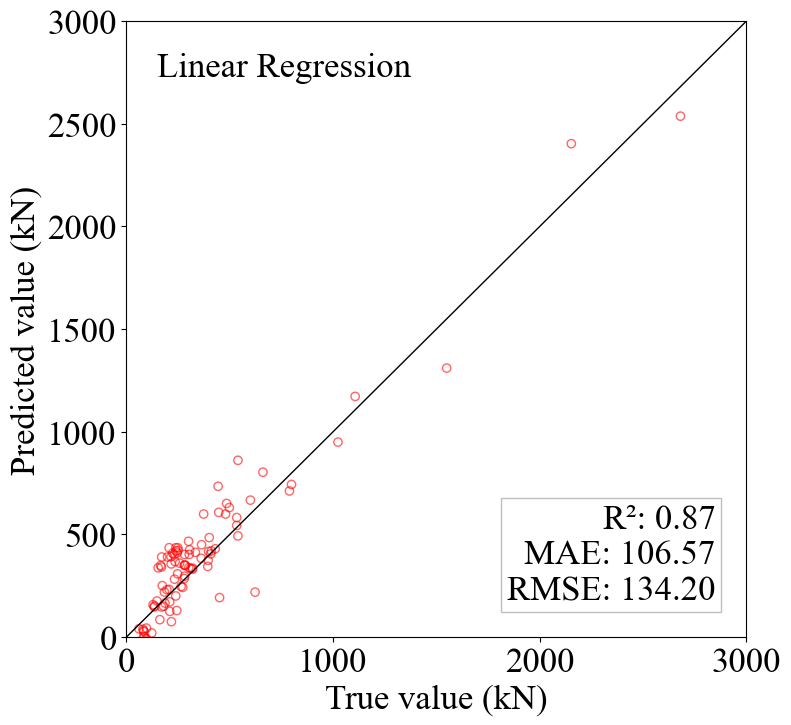

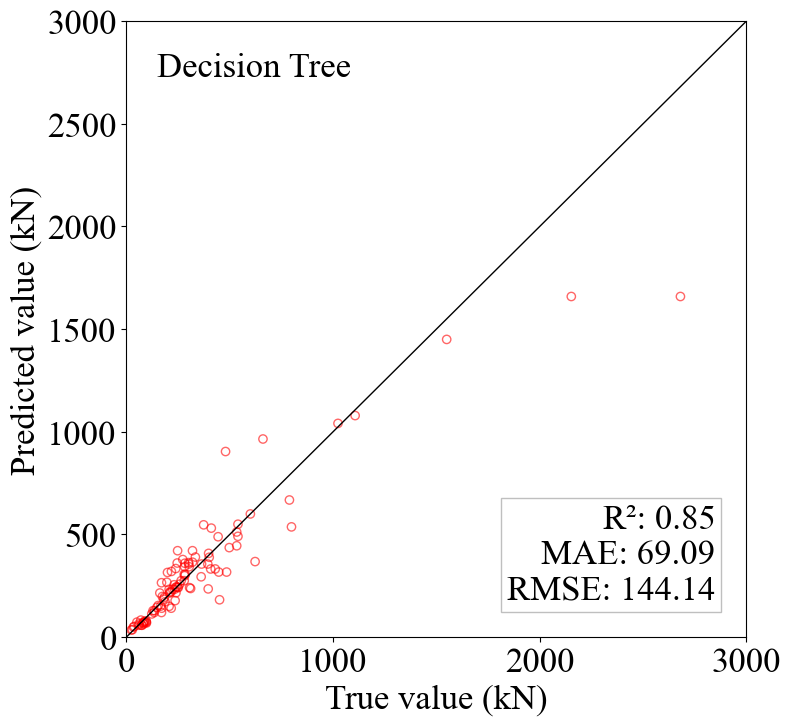

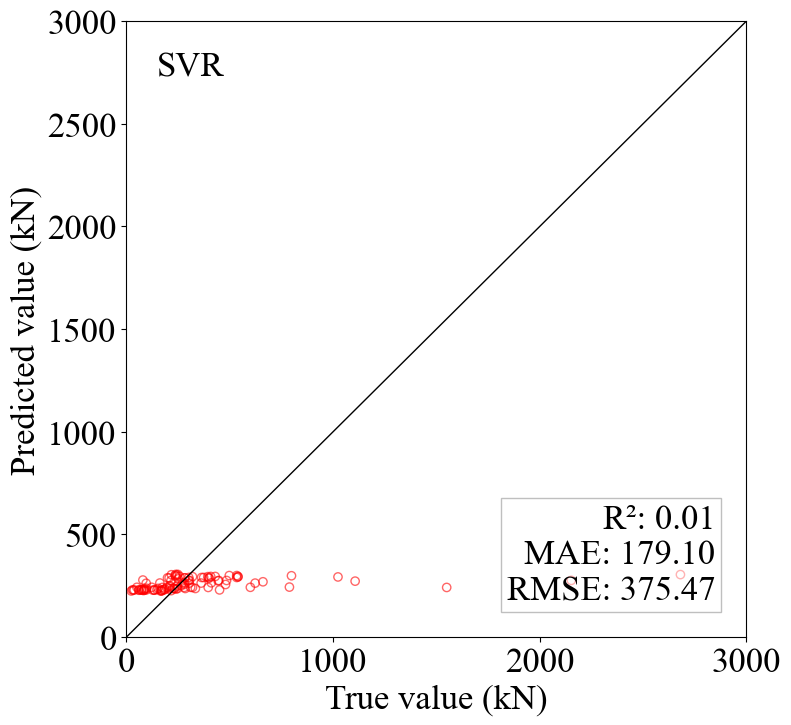

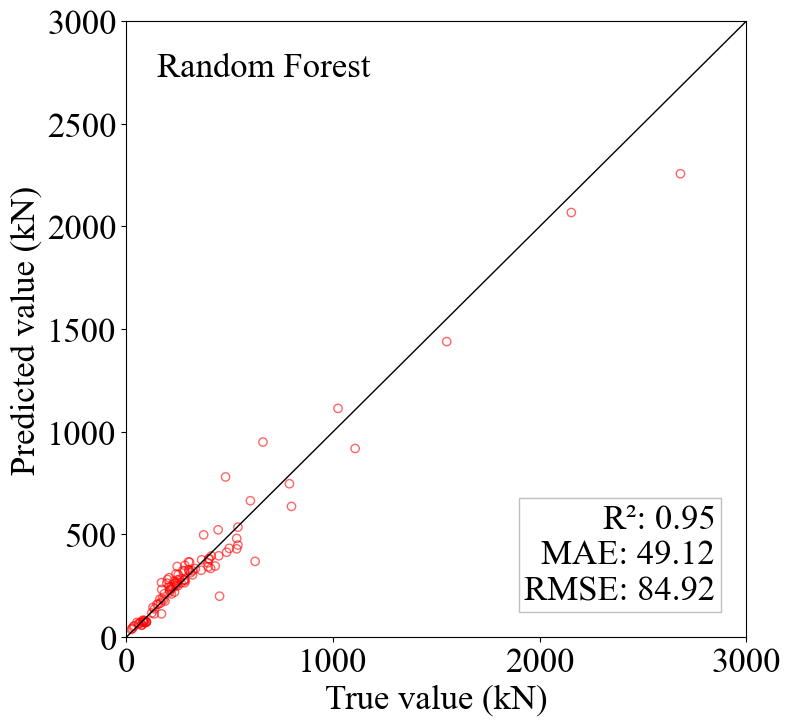

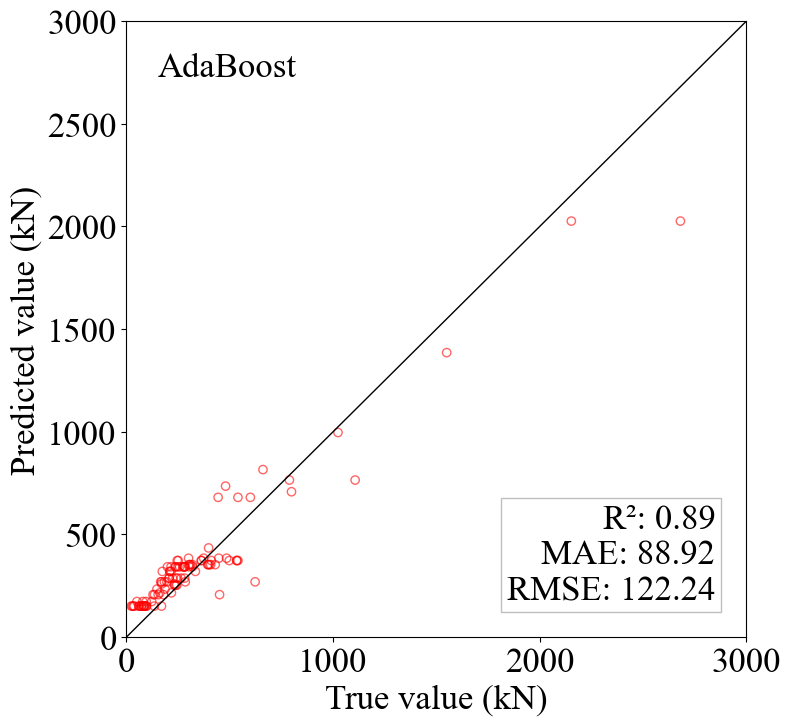

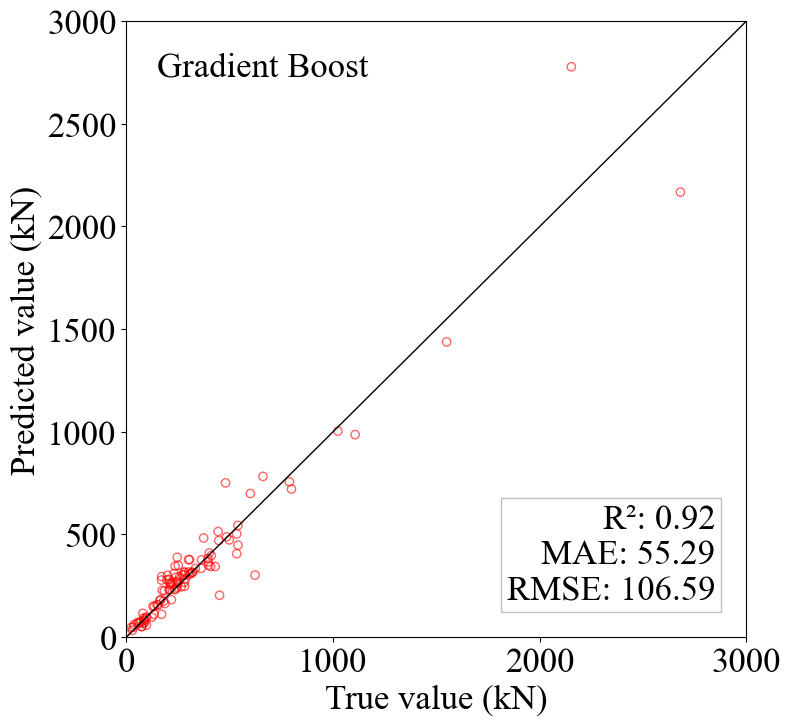

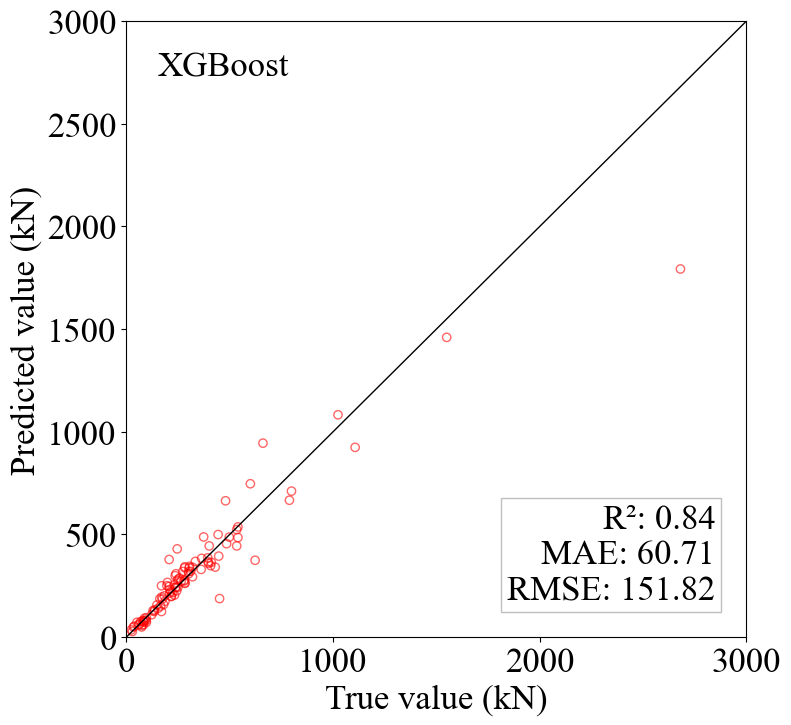

In [26]:
import matplotlib.pyplot as plt

plt.style.use("default")

# 전체 폰트 설정: Times New Roman, 14포인트
font_size = 25
plt.rc("font", family="Times New Roman", size=font_size)

# 각 모델에 대해 1:1 비교 그래프 그리기 (테스트 데이터)
for name, model in models.items():
    # 테스트 데이터에 대한 예측 수행
    y_test_pred = model.predict(X_test)

    # 평가 지표 계산 (테스트 데이터)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # 산점도 및 1:1 선 그리기
    plt.figure(figsize=(8, 8))
    # 빨간색 비어있는 동그라미로 표시
    plt.scatter(
        y_test, y_test_pred, alpha=0.6, marker="o", facecolors="none", edgecolors="red"
    )

    # 1:1 비교 선 (대각선)
    min_val = 0
    max_val = 3000
    plt.plot([min_val, max_val], [min_val, max_val], "black", lw=1)

    plt.xlabel("True value (kN)")
    plt.ylabel("Predicted value (kN)")

    # x축과 y축 범위를 0에서 5000으로 설정
    plt.xlim(0, 3000)
    plt.ylim(0, 3000)

    # 왼쪽 상단에 모델 이름 표기 (axes 좌표: 0~1)
    plt.text(
        0.05,
        0.95,
        name,
        transform=plt.gca().transAxes,
        fontsize=font_size,
        verticalalignment="top",
    )

    # 오른쪽 하단에 평가 지표 표기
    metrics_text = f"R²: {r2_test:.2f}\nMAE: {mae_test:.2f}\nRMSE: {rmse_test:.2f}"
    plt.text(
        0.95,
        0.05,
        metrics_text,
        transform=plt.gca().transAxes,
        fontsize=font_size,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="gray"),
    )

    plt.show()

### Table 7 Summary prediction results of failure mode in training set and test set.

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 분류 모델 관련 라이브러리
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
import xgboost as xgb

# 분류 성능 지표
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 데이터 불러오기
file_path = "../데이터 베이스/머신러닝 데이터.xlsx"
data = pd.read_excel(file_path)

# 2. 예측에 사용할 특징(Features)와 타깃(Target) 변수 설정
features = [
    "Shape",
    "Column_area",
    "slab's_effective_depth",
    "fc",
    "fy",
    "reinforcement_ratio",
]
target = "FM"

X = data[features]
y = data[target]

# (선택) 만약 y가 문자열이라면 숫자로 변환(라벨 인코딩)
# 예: "Punching", "Flexural" 등이 있는 경우
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

# 3. Train/Test 분할 (80%: Train, 20%: Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 모델 리스트 정의 (원래 예시의 회귀 모델을 분류 모델로 교체)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),  # SVC: Support Vector Classifier
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        random_state=42, eval_metric="mlogloss"  # 다중분류/이진분류 시 사용
    ),
}

# 5. 각 모델별 평가 지표 계산 (Train/Test Precision, Recall, F1, Accuracy)
results = []

for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)

    # 예측 수행
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # (1) Train 데이터 성능
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(
        y_train, y_train_pred, average="macro", zero_division=0
    )
    train_recall = recall_score(y_train, y_train_pred, average="macro")
    train_f1 = f1_score(y_train, y_train_pred, average="macro")

    # (2) Test 데이터 성능
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average="macro")
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # 결과 저장
    results.append(
        {
            "Model": name,
            "Train Precision": train_prec,
            "Train Recall": train_recall,
            "Train F1": train_f1,
            "Train Accuracy": train_acc,
            "Test Precision": test_prec,
            "Test Recall": test_recall,
            "Test F1": test_f1,
            "Test Accuracy": test_acc,
        }
    )

# 6. 결과를 DataFrame으로 정리하여 출력
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Train Precision  Train Recall  Train F1  \
0  Logistic Regression         0.848393      0.575613  0.590920   
1        Decision Tree         1.000000      1.000000  1.000000   
2                  SVM         0.414216      0.500000  0.453083   
3        Random Forest         1.000000      1.000000  1.000000   
4             AdaBoost         0.889946      0.742604  0.789853   
5       Gradient Boost         0.985114      0.962806  0.973529   
6              XGBoost         0.998525      0.992857  0.995664   

   Train Accuracy  Test Precision  Test Recall   Test F1  Test Accuracy  
0        0.850490        0.685000     0.530032  0.525266       0.862745  
1        1.000000        0.710227     0.710227  0.710227       0.862745  
2        0.828431        0.431373     0.500000  0.463158       0.862745  
3        1.000000        0.779720     0.727273  0.749274       0.892157  
4        0.901961        0.963158     0.750000  0.814208       0.931373  
5        0.985294  

### Fig.9. Confusion matrices of ML models in training set.

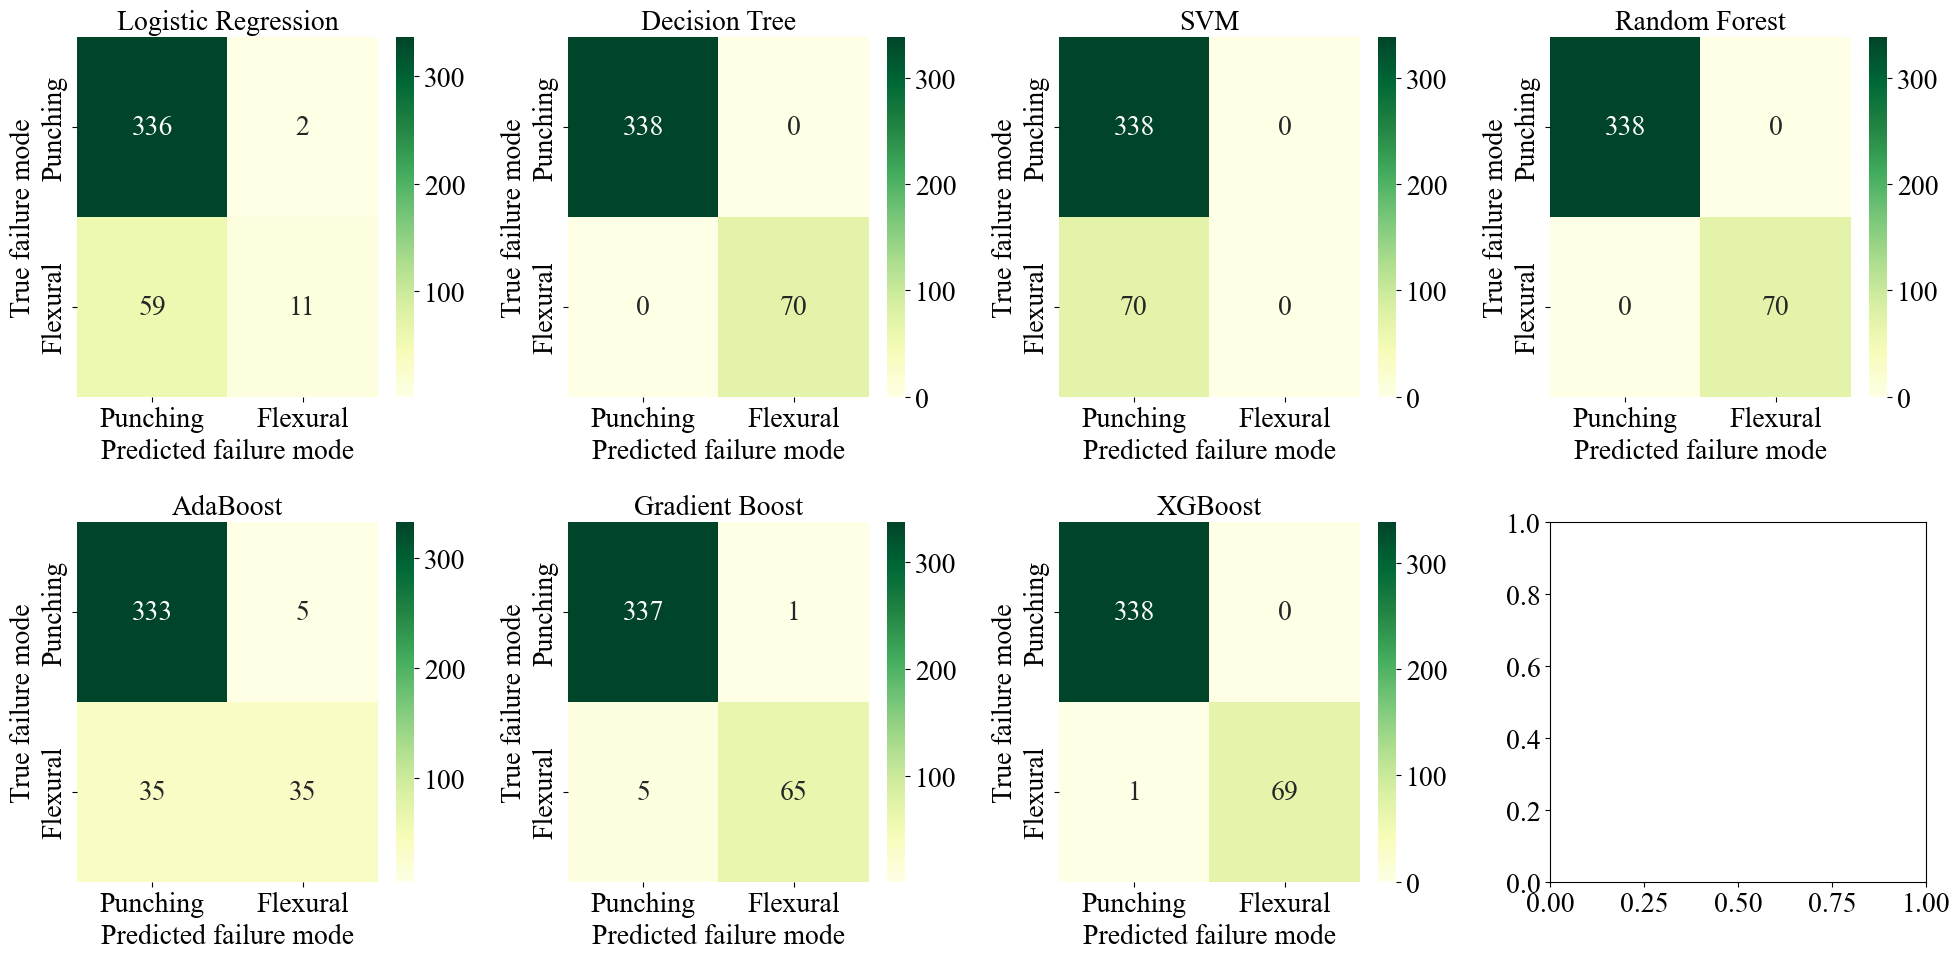


[트레인 데이터 성능 지표 요약]
                 Model  Train Precision  Train Recall  Train F1  \
0  Logistic Regression         0.848393      0.575613  0.590920   
1        Decision Tree         1.000000      1.000000  1.000000   
2                  SVM         0.414216      0.500000  0.453083   
3        Random Forest         1.000000      1.000000  1.000000   
4             AdaBoost         0.889946      0.742604  0.789853   
5       Gradient Boost         0.985114      0.962806  0.973529   
6              XGBoost         0.998525      0.992857  0.995664   

   Train Accuracy  
0        0.850490  
1        1.000000  
2        0.828431  
3        1.000000  
4        0.901961  
5        0.985294  
6        0.997549  


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 분류 모델 관련 라이브러리
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
import xgboost as xgb

# 분류 성능 지표, 혼동 행렬
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
file_path = "../데이터 베이스/머신러닝 데이터.xlsx"
data = pd.read_excel(file_path)

# 2. 예측에 사용할 특징(Features)와 타깃(Target) 변수 설정
features = [
    "Shape",
    "Column_area",
    "slab's_effective_depth",
    "fc",
    "fy",
    "reinforcement_ratio",
]
target = "FM"

# 폰트 사이즈를 20으로 설정
font_size = 20

X = data[features]
y = data[target]

# (선택) y가 문자열인 경우 필요한 경우 라벨 인코딩 수행
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

# 3. Train/Test 분할 (여기서는 트레인 데이터를 기준으로 사용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 모델 리스트 정의
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="mlogloss"),
}

# 전역 폰트 설정 (Times New Roman, 폰트 사이즈 20)
plt.rc("font", family="Times New Roman", size=font_size)

# 혼동 행렬에 사용할 클래스 레이블 매핑 (0 -> Punching, 1 -> Flexural)
label_mapping = {0: "Punching", 1: "Flexural"}

# ----------------------------------------------------------------------
# 모델 학습 및 혼동 행렬 시각화 (트레인 데이터 기준)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2행 4열 서브플롯
axes = axes.ravel()  # 1차원 배열로 변환

for i, (name, model) in enumerate(models.items()):
    # 모델 학습
    model.fit(X_train, y_train)
    # 트레인 데이터 예측
    y_train_pred = model.predict(X_train)

    # 혼동 행렬 계산 (트레인 데이터 기준)
    cm = confusion_matrix(y_train, y_train_pred)

    # 히트맵 시각화
    sns.heatmap(
        cm,
        annot=True,  # 셀 안에 숫자 표시
        fmt="d",  # 정수 형태로 표시
        cmap="YlGn",  # 색상 맵 (원하는 경우 'Reds'나 'Blues' 등으로 변경 가능)
        cbar=True,
        ax=axes[i],
    )

    # 축 라벨 설정: 모델이 인식한 클래스 순서(model.classes_)
    if hasattr(model, "classes_"):
        classes_ = model.classes_
        # 매핑된 레이블 생성 (예: 0 -> "Punching", 1 -> "Flexural")
        mapped_labels = [label_mapping.get(c, c) for c in classes_]
        # x축: 가로로 표시 (회전 0도), y축: 세로로 표시 (회전 90도)
        axes[i].set_xticklabels(mapped_labels, rotation=0, ha="center", fontsize=font_size)
        axes[i].set_yticklabels(mapped_labels, rotation=90, fontsize=font_size)
    axes[i].set_title(name, fontsize=font_size)
    axes[i].set_xlabel("Predicted failure mode", fontsize=font_size)
    axes[i].set_ylabel("True failure mode", fontsize=font_size)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 트레인 데이터 성능 지표 (Precision, Recall, F1, Accuracy) 계산
# ----------------------------------------------------------------------
results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)

    # 트레인 데이터 성능 지표 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, average="macro", zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, average="macro")
    train_f1 = f1_score(y_train, y_train_pred, average="macro")

    results.append(
        {
            "Model": name,
            "Train Precision": train_prec,
            "Train Recall": train_recall,
            "Train F1": train_f1,
            "Train Accuracy": train_acc,
        }
    )

results_df = pd.DataFrame(results)
print("\n[트레인 데이터 성능 지표 요약]")
print(results_df)


### Fig.10. Confusion matrices of ML models in test set.

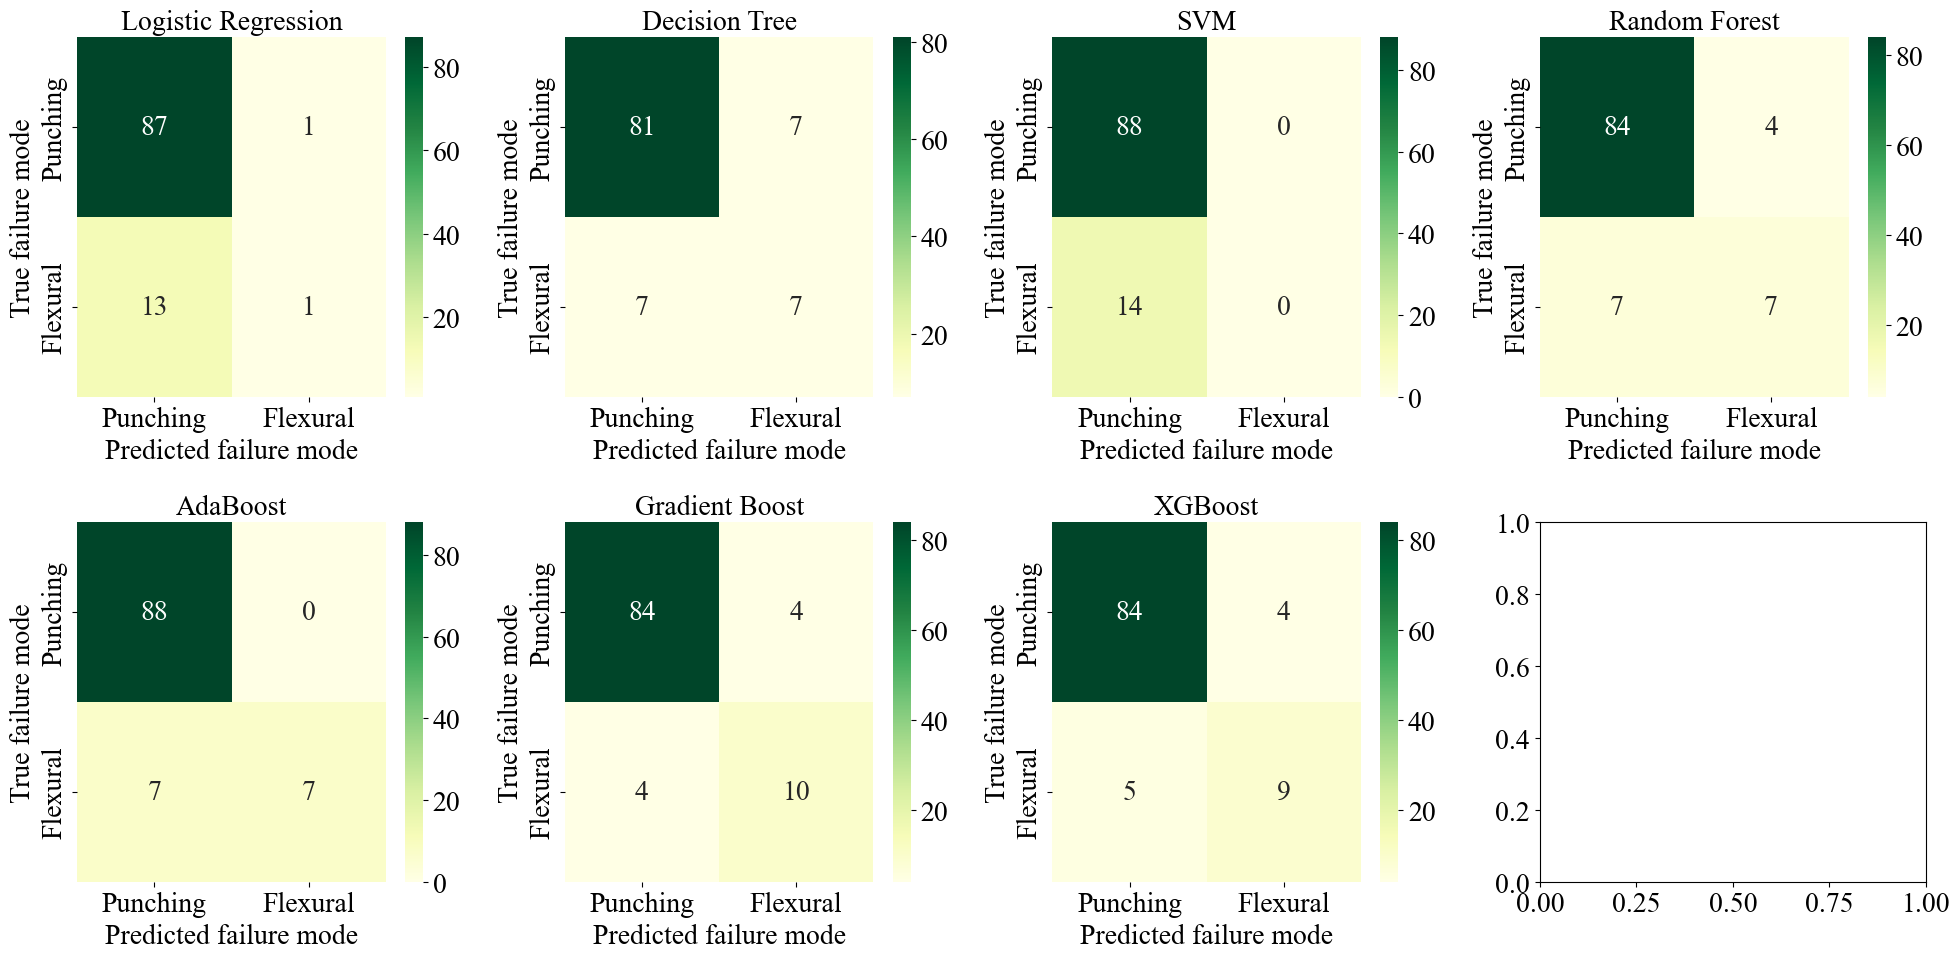


[테스트 데이터 성능 지표 요약]
                 Model  Test Precision  Test Recall   Test F1  Test Accuracy
0  Logistic Regression        0.685000     0.530032  0.525266       0.862745
1        Decision Tree        0.710227     0.710227  0.710227       0.862745
2                  SVM        0.431373     0.500000  0.463158       0.862745
3        Random Forest        0.779720     0.727273  0.749274       0.892157
4             AdaBoost        0.963158     0.750000  0.814208       0.931373
5       Gradient Boost        0.834416     0.834416  0.834416       0.921569
6              XGBoost        0.818064     0.798701  0.807910       0.911765


In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 분류 모델 관련 라이브러리
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
import xgboost as xgb

# 분류 성능 지표, 혼동 행렬
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
file_path = "../데이터 베이스/머신러닝 데이터.xlsx"
data = pd.read_excel(file_path)

# 2. 예측에 사용할 특징(Features)와 타깃(Target) 변수 설정
features = [
    "Shape",
    "Column_area",
    "slab's_effective_depth",
    "fc",
    "fy",
    "reinforcement_ratio",
]
target = "FM"

# 폰트 사이즈를 20으로 설정
font_size = 20

X = data[features]
y = data[target]

# (선택) y가 문자열인 경우 필요한 경우 라벨 인코딩 수행
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

# 3. Train/Test 분할 (여기서는 테스트 데이터를 기준으로 사용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 모델 리스트 정의
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="mlogloss"),
}

# 전역 폰트 설정 (Times New Roman, 폰트 사이즈 20)
plt.rc("font", family="Times New Roman", size=font_size)

# 혼동 행렬에 사용할 클래스 레이블 매핑 (0 -> Punching, 1 -> Flexural)
label_mapping = {0: "Punching", 1: "Flexural"}

# ----------------------------------------------------------------------
# 모델 학습 후 테스트 데이터 기준 혼동 행렬 시각화
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2행 4열 서브플롯
axes = axes.ravel()  # 1차원 배열로 변환

for i, (name, model) in enumerate(models.items()):
    # 모델은 트레인 데이터로 학습
    model.fit(X_train, y_train)
    # 테스트 데이터에 대해 예측 수행
    y_test_pred = model.predict(X_test)

    # 혼동 행렬 계산 (테스트 데이터 기준)
    cm = confusion_matrix(y_test, y_test_pred)

    # 히트맵 시각화
    sns.heatmap(
        cm,
        annot=True,      # 셀 안에 숫자 표시
        fmt="d",         # 정수 형태로 표시
        cmap="YlGn",     # 색상 맵
        cbar=True,
        ax=axes[i],
    )

    # 축 라벨 설정: 모델이 인식한 클래스 순서(model.classes_)
    if hasattr(model, "classes_"):
        classes_ = model.classes_
        # 매핑된 레이블 생성 (예: 0 -> "Punching", 1 -> "Flexural")
        mapped_labels = [label_mapping.get(c, c) for c in classes_]
        # x축: 가로 방향(회전 0도), y축: 세로 방향(회전 90도)
        axes[i].set_xticklabels(mapped_labels, rotation=0, ha="center", fontsize=font_size)
        axes[i].set_yticklabels(mapped_labels, rotation=90, fontsize=font_size)
    axes[i].set_title(name, fontsize=font_size)
    axes[i].set_xlabel("Predicted failure mode", fontsize=font_size)
    axes[i].set_ylabel("True failure mode", fontsize=font_size)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 테스트 데이터 성능 지표 (Precision, Recall, F1, Accuracy) 계산
# ----------------------------------------------------------------------
results_test = []

for name, model in models.items():
    # 테스트 데이터에 대해 예측 수행
    y_test_pred = model.predict(X_test)

    # 테스트 데이터 성능 지표 계산
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average="macro")
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    results_test.append(
        {
            "Model": name,
            "Test Precision": test_prec,
            "Test Recall": test_recall,
            "Test F1": test_f1,
            "Test Accuracy": test_acc,
        }
    )

results_test_df = pd.DataFrame(results_test)
print("\n[테스트 데이터 성능 지표 요약]")
print(results_test_df)


### Fig.13. Global interpretations for punching shear resistance.

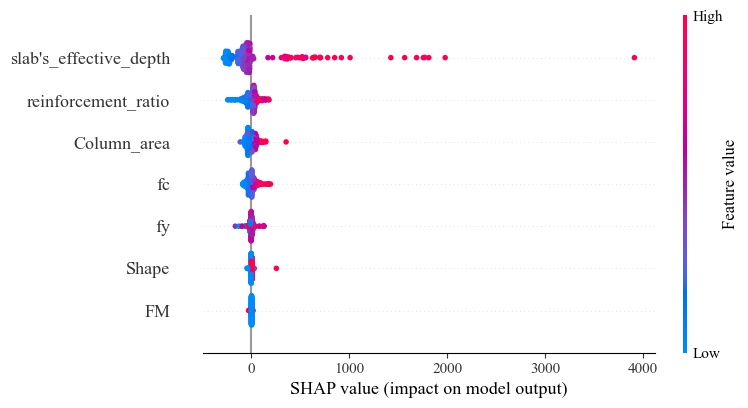

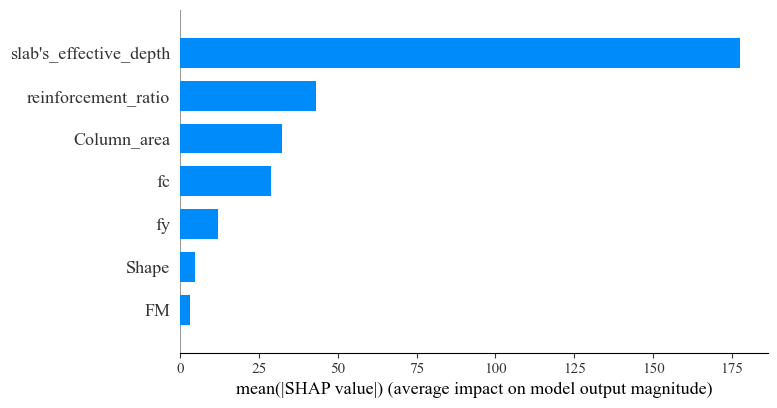

In [49]:
import shap
import matplotlib.pyplot as plt

# matplotlib 스타일 및 폰트 설정 (Times New Roman, 14포인트)
plt.style.use("default")
plt.rc("font", family="Times New Roman", size=14)

# XGBoost 모델 선택 (models 딕셔너리에서 "XGBoost" 키 사용)
xgb_model = models["XGBoost"]

# XGBoost는 트리 기반 모델이므로 TreeExplainer 사용
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)

# 1. SHAP Beeswarm Plot (개별 샘플별 SHAP 값 분포)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, plot_type="dot", show=False)
plt.show()

# 2. Mean |SHAP Value| (특징별 평균 절대 SHAP 값, 즉 중요도)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.show()


### Fig.16. Global interpretations for failure modes.

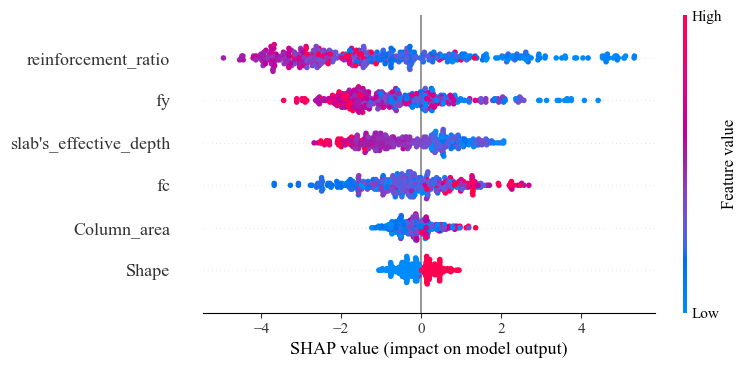

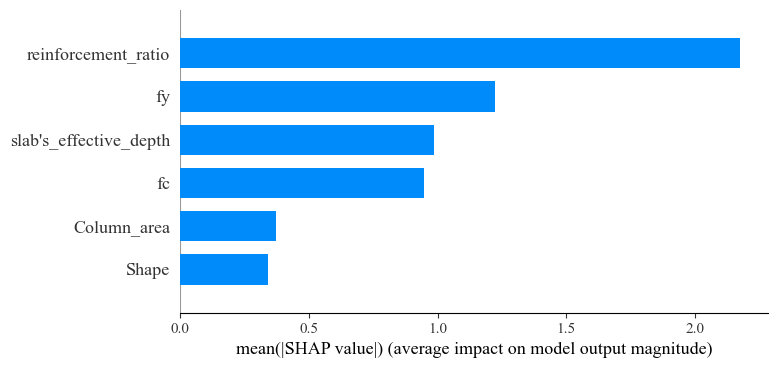

In [51]:
import shap
import matplotlib.pyplot as plt

# matplotlib 스타일 및 폰트 설정 (Times New Roman, 14포인트)
plt.style.use("default")
plt.rc("font", family="Times New Roman", size=14)

# models 딕셔너리에서 XGBoost 분류 모델 선택
xgb_model = models["XGBoost"]

# XGBoost는 트리 기반 모델이므로 TreeExplainer 사용
explainer = shap.TreeExplainer(xgb_model)

# 분류 문제의 경우, shap_values가 클래스별 리스트 형태로 반환될 수 있습니다.
# 여기서는 예시로 첫 번째 클래스(인덱스 0)의 SHAP 값을 선택합니다.
shap_values = explainer.shap_values(X_train)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[0]
else:
    shap_values_to_plot = shap_values

# 1. SHAP Beeswarm Plot (각 샘플별 SHAP 값 분포)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_train, plot_type="dot", show=False)
plt.show()

# 2. Mean |SHAP Value| Bar Plot (특징별 평균 절대 SHAP 값)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_train, plot_type="bar", show=False)
plt.show()
